# Structure-free invariant autoencoders v2: corrected comparison and diagnostics

This notebook continues `phase_separation_fully_equivariant_graph_autoencoder.ipynb` but removes every Steinhardt/CNA/PTM target. It asks whether a **single global latent vector** can describe an unordered 18-neighbor environment and reconstruct its geometry without knowing its input orientation.

The contract is

$$z(PXR^\top)=z(X),\qquad \hat X(PXR^\top)=\hat X(X),$$

where $P$ permutes neighbors and $R\in SO(3)$. Intermediate particle features are necessarily permutation equivariant; after global pooling the latent and canonical decoded set are invariant. Decoder output slots have no particle identity, and all reconstruction losses treat them as an unordered set.

Four study blocks are implemented:

1. **Invariant distance GNN + fused Gromov–Wasserstein (FGW)**.
2. **Loss study on the same GNN:** sorted distances, Sinkhorn–Kabsch, and anchor-frame Chamfer versus FGW.
3. **Invariant distance-aware Set Transformer + FGW**.
4. **Continuous steerable point convolution + invariant pooling + FGW**.

Every model/loss combination runs in three regimes: clean autoencoding, Gaussian denoising, and masked-neighbor reconstruction. Every trained model is then evaluated on the **same clean, noisy, and masked test conditions**, so training effects are not confounded with evaluation corruption. Phase labels are evaluation-only.


## Experimental map

| study | encoder | latent | decoder | reconstruction loss |
|---|---|---|---|---|
| E1 | distance message passing | global scalar vector | canonical unordered point set | fused GW |
| E2 | same distance GNN | same | same | sorted distances / Sinkhorn–Kabsch / anchor frame |
| E3 | distance-biased self-attention | global scalar vector | same | fused GW |
| E4 | spherical-harmonic continuous filters | pooled irrep norms → global scalar vector | same | fused GW |

Spherical harmonics in E4 are only a rotation-group basis used inside learned filters. No $q_l$, $w_l$, structure label, or descriptor is loaded or predicted.

The anchor loss is the computationally tractable version of the proposed center-plus-three-neighbor alignment. It constructs a frame from three geometrically selected anchors. Its expected weakness—discontinuous anchor changes near symmetric/tied configurations—is part of the comparison.


In [1]:
# Imports
import gc
import os
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# e3nn 0.4.x bundles trusted local Wigner constants containing Python slices.
# PyTorch >=2.6 requires explicitly allow-listing that harmless built-in type.
try:
    torch.serialization.add_safe_globals([slice])
except AttributeError:
    pass

try:
    import e3nn
    from e3nn import o3
    from e3nn.nn import NormActivation
    E3NN_AVAILABLE = True
    warnings.filterwarnings(
        "ignore",
        message="The TorchScript type system doesn't support instance-level annotations.*",
        category=UserWarning,
    )
except Exception as error:
    E3NN_AVAILABLE = False
    E3NN_IMPORT_ERROR = repr(error)


In [2]:
# Shared configuration
PHASES = ("liquid", "fcc", "hcp")
LABEL_MAP = {phase: i for i, phase in enumerate(PHASES)}
LABEL_COLORS = {"liquid": "tab:green", "fcc": "tab:blue", "hcp": "tab:orange"}
DATA_FILENAME = "particle_data_second_shell.npz"
N_NEIGHBORS = 18
N_NODES = N_NEIGHBORS + 1

MAIN_SEED = 42
ROBUSTNESS_SEEDS = (42, 43, 44, 45, 46)
MAX_SAMPLES_PER_PHASE = 1_200
VAL_FRACTION = 0.20
TEST_FRACTION = 0.20

LATENT_DIMENSIONS = (16, 32, 64)  # use 32 in the main matrix; ablation hook below
LATENT_DIM = 32
HIDDEN_DIM = 48
N_ENCODER_LAYERS = 3
RBF_DIM = 12
BATCH_SIZE = 96
MAX_EPOCHS = 28
STEERABLE_MAX_EPOCHS = 45
PATIENCE = 7
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 5.0

DENOISE_SIGMA = 0.05          # relative to median training neighbor radius
MASK_FRACTION = 0.25
REGIMES = ("clean", "denoise", "masked")

FGW_OUTER_STEPS = 4
SINKHORN_STEPS = 12
SINKHORN_TEMPERATURE = 0.08
FGW_RADIAL_WEIGHT = 0.5

EVAL_MAX_SAMPLES = 500
NOISE_LEVELS = (0.01, 0.03, 0.05, 0.10)
MASK_LEVELS = (0.10, 0.20, 0.30)
EVALUATION_CONDITIONS = {
    "clean": {"regime": "clean"},
    f"noise_{DENOISE_SIGMA:.2f}": {"regime": "denoise", "noise_sigma": DENOISE_SIGMA},
    f"mask_{MASK_FRACTION:.2f}": {"regime": "masked", "mask_fraction": MASK_FRACTION},
}
RUN_MAIN_BENCHMARK = True
RUN_PRIMARY_FIVE_SEED_ROBUSTNESS = False  # 45 fits: E1/E3/E4 × 3 regimes × 5 seeds
RUN_LATENT_WIDTH_ABLATION = False
RUN_CORRUPTION_STRENGTH_ABLATION = False
RUN_LATENT_REGULARIZATION_ABLATION = False
RUN_PARAMETER_MATCHED_ABLATION = False

if os.environ.get("AE_SMOKE_TEST") == "1":
    MAX_SAMPLES_PER_PHASE = 12
    BATCH_SIZE = 12
    MAX_EPOCHS = 1
    STEERABLE_MAX_EPOCHS = 1
    PATIENCE = 1
    HIDDEN_DIM = 16
    N_ENCODER_LAYERS = 1
    FGW_OUTER_STEPS = 2
    SINKHORN_STEPS = 4
    EVAL_MAX_SAMPLES = 24

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("e3nn available:", E3NN_AVAILABLE, getattr(e3nn, "__version__", None) if E3NN_AVAILABLE else E3NN_IMPORT_ERROR)
print("Planned main fits:", 6 * len(REGIMES))
print("Smoke test:", os.environ.get("AE_SMOKE_TEST") == "1")


Device: cuda
e3nn available: True 0.4.4
Planned main fits: 18
Smoke test: False


## 1. Data and leakage-safe sampling

Only `vec_dist`, particle IDs, and frame indices are loaded. The available 18-neighbor geometry is used directly; its stored structural descriptors are intentionally ignored.

Whole frames are split into train/validation/test partitions independently within each phase. The coordinate scale is fitted on training frames. One balanced sample and frame split is shared by every experiment.


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def locate_data_dir():
    candidates = (
        Path("."),
        Path("lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
        Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
    )
    for root in candidates:
        if all((root / phase / DATA_FILENAME).exists() for phase in PHASES):
            return root
    raise FileNotFoundError(f"Could not locate {DATA_FILENAME} for all phases")


def split_whole_frames(frame_indices, rng):
    frames = rng.permutation(np.unique(frame_indices))
    n_test = max(1, round(TEST_FRACTION * len(frames)))
    n_val = max(1, round(VAL_FRACTION * len(frames)))
    split = np.full(len(frame_indices), "train", dtype="<U5")
    split[np.isin(frame_indices, frames[:n_test])] = "test"
    split[np.isin(frame_indices, frames[n_test:n_test + n_val])] = "val"
    return split


def prepare_dataset(seed=MAIN_SEED):
    root = locate_data_dir()
    rng = np.random.default_rng(seed)
    raw = {}
    for phase in PHASES:
        with np.load(root / phase / DATA_FILENAME, allow_pickle=True) as npz:
            raw[phase] = {
                "vectors": np.asarray(npz["vec_dist"], dtype=np.float32),
                "frame_indices": np.asarray(npz["frame_indices"], dtype=np.int64),
            }
        if raw[phase]["vectors"].shape[1:] != (N_NEIGHBORS, 3):
            raise ValueError(f"Unexpected shape for {phase}: {raw[phase]['vectors'].shape}")

    n_per_phase = min(MAX_SAMPLES_PER_PHASE, *(len(raw[p]["vectors"]) for p in PHASES))
    coordinates, labels, splits, rows = [], [], [], []
    for phase in PHASES:
        selected = np.sort(rng.choice(len(raw[phase]["vectors"]), n_per_phase, replace=False))
        frames = raw[phase]["frame_indices"][selected]
        local_split = split_whole_frames(frames, rng)
        center = np.zeros((n_per_phase, 1, 3), dtype=np.float32)
        coordinates.append(np.concatenate([center, raw[phase]["vectors"][selected]], axis=1))
        labels.append(np.full(n_per_phase, LABEL_MAP[phase], dtype=np.int64))
        splits.append(local_split)
        rows.append({
            "phase": phase,
            "samples": n_per_phase,
            **{f"{part}_frames": np.unique(frames[local_split == part]).size
               for part in ("train", "val", "test")},
        })

    coordinates = np.concatenate(coordinates)
    labels = np.concatenate(labels)
    split = np.concatenate(splits)
    train = split == "train"
    scale = float(np.median(np.linalg.norm(coordinates[train, 1:], axis=-1)))
    coordinates = (coordinates / scale).astype(np.float32)
    return {
        "coordinates": coordinates,
        "labels": labels,
        "split": split,
        "coordinate_scale": scale,
        "summary": pd.DataFrame(rows),
        "root": root,
    }


set_seed(MAIN_SEED)
dataset = prepare_dataset()
display(dataset["summary"])
print("Data:", dataset["root"].resolve())
print("Training coordinate scale:", dataset["coordinate_scale"])


,phase,samples,train_frames,val_frames,test_frames
0,liquid,1200,176,58,58
1,fcc,1200,321,107,107
2,hcp,1200,308,102,102


Data: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
Training coordinate scale: 1.1289727687835693


## 2. Three training regimes

- **Clean:** reconstruct the same neighborhood.
- **Denoise:** add isotropic Gaussian displacement noise to observed neighbors and reconstruct the clean set.
- **Masked:** hide 25% of neighbor coordinates, pass an observed/not-observed scalar to the encoder, and reconstruct the complete set.

Training inputs and targets also receive random rotations and independent neighbor permutations. These augmentations should be mathematically redundant; they act as executable guards against accidental ordering or orientation leakage.


In [4]:
def random_rotation_matrices(batch_size, device, generator):
    q = torch.randn(batch_size, 4, device=device, generator=generator)
    q = q / q.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    w, x, y, z = q.unbind(-1)
    return torch.stack([
        1 - 2 * (y*y + z*z), 2 * (x*y - z*w), 2 * (x*z + y*w),
        2 * (x*y + z*w), 1 - 2 * (x*x + z*z), 2 * (y*z - x*w),
        2 * (x*z - y*w), 2 * (y*z + x*w), 1 - 2 * (x*x + y*y),
    ], dim=-1).reshape(batch_size, 3, 3)


def permute_neighbors(coordinates, generator):
    order = torch.argsort(
        torch.rand(len(coordinates), N_NEIGHBORS, device=coordinates.device, generator=generator),
        dim=1,
    ) + 1
    order = torch.cat([torch.zeros(len(coordinates), 1, dtype=torch.long, device=coordinates.device), order], dim=1)
    return torch.gather(coordinates, 1, order.unsqueeze(-1).expand(-1, -1, 3))


def prepare_regime_batch(
    clean,
    regime,
    generator,
    augment=False,
    noise_sigma=None,
    mask_fraction=None,
):
    target = clean
    if augment:
        target = permute_neighbors(target, generator)
        rotations = random_rotation_matrices(len(target), target.device, generator)
        target = target @ rotations.transpose(-1, -2)

    observed = torch.ones(len(target), N_NODES, 1, device=target.device)
    corrupted = target.clone()
    if regime == "denoise":
        noise_sigma = DENOISE_SIGMA if noise_sigma is None else noise_sigma
        noise = torch.randn(corrupted.shape, device=corrupted.device, generator=generator)
        corrupted[:, 1:] += noise_sigma * noise[:, 1:]
    elif regime == "masked":
        mask_fraction = MASK_FRACTION if mask_fraction is None else mask_fraction
        n_mask = max(1, round(mask_fraction * N_NEIGHBORS))
        choices = torch.argsort(
            torch.rand(len(target), N_NEIGHBORS, device=target.device, generator=generator), dim=1
        )[:, :n_mask] + 1
        observed.scatter_(1, choices.unsqueeze(-1), 0.0)
        corrupted = corrupted * observed
    elif regime != "clean":
        raise KeyError(regime)
    return corrupted, observed, target


## 3. Rotation- and permutation-independent reconstruction losses

All losses compare the center plus an unordered neighbor set. FGW uses internal neighbor distances plus radii to the distinguished center. Sinkhorn–Kabsch alternates a soft distance-signature assignment and a proper rotation. The anchor loss canonicalizes each cloud using three geometry-selected directions and then applies symmetric Chamfer distance.

Sorted distances are deliberately included as a weak baseline: they are cheap and invariant, but different geometries can share the same distance multiset.


In [5]:
def neighbor_points(coordinates):
    return coordinates[:, 1:]


def pairwise_distances(points):
    return torch.cdist(points, points)


def sorted_full_distance_loss(prediction, target):
    dp = torch.cdist(prediction, prediction)
    dt = torch.cdist(target, target)
    i, j = torch.triu_indices(N_NODES, N_NODES, offset=1, device=prediction.device)
    return F.smooth_l1_loss(dp[:, i, j].sort(dim=-1).values, dt[:, i, j].sort(dim=-1).values)


def log_sinkhorn(cost, temperature=SINKHORN_TEMPERATURE, steps=SINKHORN_STEPS):
    log_plan = -cost / temperature
    for _ in range(steps):
        log_plan = log_plan - torch.logsumexp(log_plan, dim=-1, keepdim=True)
        log_plan = log_plan - torch.logsumexp(log_plan, dim=-2, keepdim=True)
    return log_plan.exp()


def raw_fused_gromov_wasserstein(
    points_left,
    points_right,
    temperature=SINKHORN_TEMPERATURE,
    outer_steps=FGW_OUTER_STEPS,
    sinkhorn_steps=SINKHORN_STEPS,
):
    xp, xt = points_left, points_right
    dp, dt = pairwise_distances(xp), pairwise_distances(xt)
    rp, rt = xp.norm(dim=-1), xt.norm(dim=-1)
    n = dp.shape[-1]
    node_cost = (rp[:, :, None] - rt[:, None, :]).square()
    plan = log_sinkhorn(node_cost, temperature=temperature, steps=sinkhorn_steps)
    for _ in range(outer_steps):
        left = dp.square().mean(dim=-1)[:, :, None]
        right = dt.square().mean(dim=-1)[:, None, :]
        cross = torch.bmm(torch.bmm(dp, plan), dt.transpose(1, 2)) / n
        cost = left + right - 2 * cross + FGW_RADIAL_WEIGHT * node_cost
        plan = log_sinkhorn(cost, temperature=temperature, steps=sinkhorn_steps)
    return (cost * plan).sum(dim=(1, 2)) / n


def fused_gromov_wasserstein_per_sample(
    prediction,
    target,
    temperature=SINKHORN_TEMPERATURE,
    outer_steps=FGW_OUTER_STEPS,
    sinkhorn_steps=SINKHORN_STEPS,
):
    """Debiased entropic FGW (a Sinkhorn-divergence-style discrepancy)."""
    xp, xt = neighbor_points(prediction), neighbor_points(target)
    kwargs = dict(temperature=temperature, outer_steps=outer_steps, sinkhorn_steps=sinkhorn_steps)
    cross = raw_fused_gromov_wasserstein(xp, xt, **kwargs)
    self_prediction = raw_fused_gromov_wasserstein(xp, xp, **kwargs)
    self_target = raw_fused_gromov_wasserstein(xt, xt, **kwargs)
    return cross - 0.5 * self_prediction - 0.5 * self_target


def fused_gromov_wasserstein_loss(prediction, target):
    return fused_gromov_wasserstein_per_sample(prediction, target).mean()


def distance_profile(points):
    distances = pairwise_distances(points).sort(dim=-1).values
    return torch.cat([points.norm(dim=-1, keepdim=True), distances], dim=-1)


def proper_kabsch(source, target):
    covariance = source.transpose(1, 2) @ target
    covariance = covariance + 1e-6 * torch.eye(3, device=source.device).unsqueeze(0)
    u, _, vh = torch.linalg.svd(covariance)
    sign = torch.det(u @ vh)
    correction = torch.eye(3, device=source.device).unsqueeze(0).repeat(len(source), 1, 1)
    correction[:, -1, -1] = sign
    return u @ correction @ vh


def raw_sinkhorn_kabsch_loss(prediction, target):
    xp, xt = neighbor_points(prediction), neighbor_points(target)
    cost = torch.cdist(distance_profile(xp), distance_profile(xt)).square()
    plan = log_sinkhorn(cost)
    aligned = xp
    for _ in range(3):
        matched_target = plan @ xt
        rotation = proper_kabsch(xp, matched_target)
        aligned = xp @ rotation
        coordinate_cost = torch.cdist(aligned, xt).square()
        plan = log_sinkhorn(coordinate_cost)
    return (coordinate_cost * plan).sum(dim=(1, 2)).mean() / N_NEIGHBORS


def sinkhorn_kabsch_loss(prediction, target):
    cross = raw_sinkhorn_kabsch_loss(prediction, target)
    self_prediction = raw_sinkhorn_kabsch_loss(prediction, prediction)
    self_target = raw_sinkhorn_kabsch_loss(target, target)
    return cross - 0.5 * self_prediction - 0.5 * self_target


def canonical_anchor_frame(points):
    batch = torch.arange(len(points), device=points.device)
    first_index = points.norm(dim=-1).argmax(dim=-1)
    e1 = F.normalize(points[batch, first_index], dim=-1, eps=1e-6)
    residual = points - (points * e1[:, None]).sum(-1, keepdim=True) * e1[:, None]
    residual_norm = residual.norm(dim=-1)
    residual_norm[batch, first_index] = -torch.inf
    second_index = residual_norm.argmax(dim=-1)
    e2 = F.normalize(residual[batch, second_index], dim=-1, eps=1e-6)
    e3 = torch.cross(e1, e2, dim=-1)
    side = (points * e3[:, None]).sum(-1)
    side[batch, first_index] = 0
    side[batch, second_index] = 0
    third_index = side.abs().argmax(dim=-1)
    orientation = torch.where(side[batch, third_index] >= 0, 1.0, -1.0).detach()
    e3 = e3 * orientation[:, None]
    e2 = torch.cross(e3, e1, dim=-1)
    frame = torch.stack([e1, e2, e3], dim=-1)
    return points @ frame


def symmetric_chamfer(left, right):
    distances = torch.cdist(left, right).square()
    return distances.min(dim=-1).values.mean() + distances.min(dim=-2).values.mean()


def anchor_frame_loss(prediction, target):
    return symmetric_chamfer(
        canonical_anchor_frame(neighbor_points(prediction)),
        canonical_anchor_frame(neighbor_points(target)),
    )


LOSS_FUNCTIONS = {
    "fgw": fused_gromov_wasserstein_loss,
    "sorted_distances": sorted_full_distance_loss,
    "sinkhorn_kabsch": sinkhorn_kabsch_loss,
    "anchor_frame": anchor_frame_loss,
}


In [6]:
# Loss-level invariance audit before any model is trained.
audit_target = torch.from_numpy(dataset["coordinates"][:4]).to(DEVICE)
audit_generator = torch.Generator(device=DEVICE).manual_seed(MAIN_SEED + 100)
audit_permuted = permute_neighbors(audit_target, audit_generator)
audit_rotation = random_rotation_matrices(len(audit_target), DEVICE, audit_generator)
audit_transformed = audit_permuted @ audit_rotation.transpose(-1, -2)

loss_audit_rows = []
for loss_name, loss_function in LOSS_FUNCTIONS.items():
    reference = loss_function(audit_target, audit_target).item()
    transformed = loss_function(audit_target, audit_transformed).item()
    loss_audit_rows.append({
        "loss": loss_name,
        "self_loss": reference,
        "rotated_permuted_loss": transformed,
        "absolute_difference": abs(reference - transformed),
    })
display(pd.DataFrame(loss_audit_rows).set_index("loss").style.format("{:.3e}"))


,self_loss,rotated_permuted_loss,absolute_difference
loss,,,
fgw,0.000e+00,1.229e-07,1.229e-07
sorted_distances,0.000e+00,1.037e-14,1.037e-14
sinkhorn_kabsch,0.000e+00,4.657e-10,4.657e-10
anchor_frame,0.000e+00,4.261e-14,4.261e-14


## 4. Shared decoder and invariant encoders

All encoders return one vector $z\in\mathbb{R}^{32}$. A shared MLP maps it to 18 canonical output slots. The center is inserted exactly at the origin. Because decoder input is invariant, input rotations and neighbor permutations must produce exactly the same output array—not merely a permuted output.


In [7]:
class MLP(nn.Module):
    def __init__(self, dimensions, layer_norm=False):
        super().__init__()
        layers = []
        for i, (left, right) in enumerate(zip(dimensions[:-1], dimensions[1:])):
            layers.append(nn.Linear(left, right))
            if i < len(dimensions) - 2:
                if layer_norm:
                    layers.append(nn.LayerNorm(right))
                layers.append(nn.SiLU())
        self.net = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.net(inputs)


class GaussianRBF(nn.Module):
    def __init__(self, n_rbf=RBF_DIM, cutoff=3.0):
        super().__init__()
        self.register_buffer("centers", torch.linspace(0, cutoff, n_rbf))
        self.gamma = float((n_rbf - 1) ** 2 / cutoff ** 2)

    def forward(self, distances):
        return torch.exp(-self.gamma * (distances - self.centers).square())


def complete_edge_index(n_nodes=N_NODES, device=None):
    receivers, senders = torch.where(~torch.eye(n_nodes, dtype=torch.bool))
    return torch.stack([receivers, senders]).to(device)


class CanonicalSetDecoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.network = MLP([latent_dim, 64, 128, N_NEIGHBORS * 3], layer_norm=True)

    def forward(self, latent):
        neighbors = self.network(latent).reshape(len(latent), N_NEIGHBORS, 3)
        center = torch.zeros(len(latent), 1, 3, device=latent.device, dtype=latent.dtype)
        return torch.cat([center, neighbors], dim=1)


class InvariantSetAutoencoder(nn.Module):
    def __init__(self, encoder, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = encoder
        self.decoder = CanonicalSetDecoder(latent_dim)

    def forward(self, coordinates, observed):
        latent = self.encoder(coordinates, observed)
        return self.decoder(latent), latent


In [8]:
class InvariantDistanceBlock(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.rbf = GaussianRBF()
        self.edge = MLP([2 * hidden_dim + RBF_DIM, hidden_dim, hidden_dim])
        self.update = MLP([2 * hidden_dim, hidden_dim, hidden_dim])
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, features, coordinates, edge_index):
        receivers, senders = edge_index
        distances = (coordinates[:, receivers] - coordinates[:, senders]).norm(dim=-1, keepdim=True)
        messages = self.edge(torch.cat([
            features[:, receivers], features[:, senders], self.rbf(distances)
        ], dim=-1))
        aggregate = torch.zeros_like(features)
        aggregate.index_add_(1, receivers, messages)
        degree = torch.bincount(receivers, minlength=features.shape[1]).to(features.dtype)
        aggregate = aggregate / degree.view(1, -1, 1).clamp_min(1)
        return self.norm(features + self.update(torch.cat([features, aggregate], dim=-1)))


class InvariantDistanceGNN(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.embedding = MLP([3, HIDDEN_DIM, HIDDEN_DIM])
        self.blocks = nn.ModuleList([InvariantDistanceBlock() for _ in range(N_ENCODER_LAYERS)])
        self.readout = MLP([3 * HIDDEN_DIM, HIDDEN_DIM, latent_dim], layer_norm=True)
        self.register_buffer("edge_index", complete_edge_index())

    def forward(self, coordinates, observed):
        marker = torch.zeros_like(observed)
        marker[:, 0] = 1
        radii = coordinates.norm(dim=-1, keepdim=True)
        features = self.embedding(torch.cat([marker, observed, radii], dim=-1))
        for block in self.blocks:
            features = block(features, coordinates, self.edge_index)
        center = features[:, 0]
        neighbors = features[:, 1:]
        pooled = torch.cat([center, neighbors.mean(dim=1), neighbors.max(dim=1).values], dim=-1)
        return self.readout(pooled)


In [9]:
class DistanceAttentionBlock(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM, n_heads=4):
        super().__init__()
        if hidden_dim % n_heads:
            raise ValueError("hidden dimension must be divisible by attention heads")
        self.n_heads = n_heads
        self.head_dim = hidden_dim // n_heads
        self.qkv = nn.Linear(hidden_dim, 3 * hidden_dim)
        self.rbf = GaussianRBF()
        self.distance_bias = MLP([RBF_DIM, hidden_dim, n_heads])
        self.output = nn.Linear(hidden_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.feed_forward = MLP([hidden_dim, 2 * hidden_dim, hidden_dim])
        self.norm2 = nn.LayerNorm(hidden_dim)

    def forward(self, features, coordinates):
        batch, nodes, hidden = features.shape
        qkv = self.qkv(features).reshape(batch, nodes, 3, self.n_heads, self.head_dim)
        q, k, v = qkv.unbind(dim=2)
        scores = torch.einsum("bihd,bjhd->bhij", q, k) / self.head_dim ** 0.5
        distances = torch.cdist(coordinates, coordinates).unsqueeze(-1)
        bias = self.distance_bias(self.rbf(distances)).permute(0, 3, 1, 2)
        attention = torch.softmax(scores + bias, dim=-1)
        context = torch.einsum("bhij,bjhd->bihd", attention, v).reshape(batch, nodes, hidden)
        features = self.norm1(features + self.output(context))
        return self.norm2(features + self.feed_forward(features))


class InvariantSetTransformer(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.embedding = MLP([3, hidden_dim, hidden_dim])
        self.blocks = nn.ModuleList([
            DistanceAttentionBlock(hidden_dim=hidden_dim) for _ in range(N_ENCODER_LAYERS)
        ])
        self.pool_score = nn.Linear(hidden_dim, 1)
        self.readout = MLP([2 * hidden_dim, hidden_dim, latent_dim], layer_norm=True)

    def forward(self, coordinates, observed):
        marker = torch.zeros_like(observed)
        marker[:, 0] = 1
        radii = coordinates.norm(dim=-1, keepdim=True)
        features = self.embedding(torch.cat([marker, observed, radii], dim=-1))
        for block in self.blocks:
            features = block(features, coordinates)
        attention = torch.softmax(self.pool_score(features[:, 1:]), dim=1)
        pooled = (attention * features[:, 1:]).sum(dim=1)
        return self.readout(torch.cat([features[:, 0], pooled], dim=-1))


### Continuous steerable convolution encoder

The E4 encoder creates edge filters from a learned radial network and real spherical harmonics. Tensor products enforce the rotation rules. Node irreps are pooled over particles; scalar channels are retained and non-scalar irreps are reduced by their norms. That final contraction produces the same kind of global invariant latent used by the other encoders.


In [10]:
if E3NN_AVAILABLE:
    class SteerablePointConv(nn.Module):
        def __init__(self, irreps_in, irreps_out, lmax=3):
            super().__init__()
            self.irreps_in = o3.Irreps(irreps_in)
            self.irreps_out = o3.Irreps(irreps_out)
            self.irreps_sh = o3.Irreps.spherical_harmonics(lmax)
            self.rbf = GaussianRBF()
            self.tensor_product = o3.FullyConnectedTensorProduct(
                self.irreps_in, self.irreps_sh, self.irreps_out,
                internal_weights=False, shared_weights=False,
            )
            self.radial = MLP([RBF_DIM, 48, self.tensor_product.weight_numel])
            self.self_connection = o3.Linear(self.irreps_in, self.irreps_out)
            self.activation = NormActivation(self.irreps_out, F.silu)

        def forward(self, features, coordinates, edge_index):
            receivers, senders = edge_index
            relative = coordinates[:, receivers] - coordinates[:, senders]
            distances = relative.norm(dim=-1, keepdim=True)
            harmonics = o3.spherical_harmonics(
                self.irreps_sh, relative, normalize=True, normalization="component"
            )
            weights = self.radial(self.rbf(distances))
            messages = self.tensor_product(features[:, senders], harmonics, weights)
            aggregate = torch.zeros(
                len(features), features.shape[1], self.irreps_out.dim,
                device=features.device, dtype=features.dtype,
            )
            aggregate.index_add_(1, receivers, messages)
            degree = torch.bincount(receivers, minlength=features.shape[1]).to(features.dtype)
            aggregate = aggregate / degree.view(1, -1, 1).clamp_min(1)
            output = self.self_connection(features) + aggregate
            return self.activation(output.reshape(-1, self.irreps_out.dim)).reshape(
                len(features), features.shape[1], self.irreps_out.dim
            )


    class SteerableInvariantEncoder(nn.Module):
        def __init__(self, latent_dim=LATENT_DIM):
            super().__init__()
            self.irreps_input = o3.Irreps("3x0e")
            multiplicity_scale = 1 if HIDDEN_DIM >= 32 else 0.5
            m = lambda value: max(1, round(value * multiplicity_scale))
            self.irreps_hidden = o3.Irreps(
                f"{m(20)}x0e + {m(8)}x1o + {m(4)}x2e + {m(2)}x3o + {m(2)}x4e"
            )
            irreps_sequence = [self.irreps_input] + [self.irreps_hidden] * N_ENCODER_LAYERS
            self.layers = nn.ModuleList([
                SteerablePointConv(left, right)
                for left, right in zip(irreps_sequence[:-1], irreps_sequence[1:])
            ])
            invariant_dim = sum(mul for mul, _ in self.irreps_hidden)
            self.readout = MLP([invariant_dim, HIDDEN_DIM, latent_dim], layer_norm=True)
            self.register_buffer("edge_index", complete_edge_index())

        def invariant_contraction(self, pooled):
            invariants = []
            for (mul, irrep), slc in zip(self.irreps_hidden, self.irreps_hidden.slices()):
                block = pooled[:, slc].reshape(len(pooled), mul, irrep.dim)
                if irrep.l == 0:
                    invariants.append(block.squeeze(-1))
                else:
                    invariants.append(block.norm(dim=-1))
            return torch.cat(invariants, dim=-1)

        def forward(self, coordinates, observed):
            marker = torch.zeros_like(observed)
            marker[:, 0] = 1
            radii = coordinates.norm(dim=-1, keepdim=True)
            features = torch.cat([marker, observed, radii], dim=-1)
            for layer in self.layers:
                features = layer(features, coordinates, self.edge_index)
            pooled = features.mean(dim=1)
            return self.readout(self.invariant_contraction(pooled))
else:
    class SteerableInvariantEncoder(nn.Module):
        def __init__(self, latent_dim=LATENT_DIM):
            super().__init__()
            raise RuntimeError(f"E4 requires e3nn: {E3NN_IMPORT_ERROR}")


In [11]:
ENCODER_FACTORIES = {
    "distance_gnn": InvariantDistanceGNN,
    "set_transformer": InvariantSetTransformer,
    "steerable_conv": SteerableInvariantEncoder,
}

# E1's FGW row is also the FGW reference in E2; it is trained only once.
EXPERIMENT_SPECS = [
    {"study": "E1/E2", "name": "distance_gnn__fgw", "encoder": "distance_gnn", "loss": "fgw"},
    {"study": "E2", "name": "distance_gnn__sorted", "encoder": "distance_gnn", "loss": "sorted_distances"},
    {"study": "E2", "name": "distance_gnn__sinkhorn_kabsch", "encoder": "distance_gnn", "loss": "sinkhorn_kabsch"},
    {"study": "E2", "name": "distance_gnn__anchor", "encoder": "distance_gnn", "loss": "anchor_frame"},
    {"study": "E3", "name": "set_transformer__fgw", "encoder": "set_transformer", "loss": "fgw"},
    {"study": "E4", "name": "steerable_conv__fgw", "encoder": "steerable_conv", "loss": "fgw"},
]
for spec in EXPERIMENT_SPECS:
    spec.setdefault("latent_dim", LATENT_DIM)
    spec.setdefault("latent_regularization", 0.0)

PRIMARY_EXPERIMENT_NAMES = (
    "distance_gnn__fgw", "set_transformer__fgw", "steerable_conv__fgw"
)


def build_autoencoder(spec):
    latent_dim = spec.get("latent_dim", LATENT_DIM)
    encoder = ENCODER_FACTORIES[spec["encoder"]](
        latent_dim=latent_dim, **spec.get("encoder_kwargs", {})
    )
    return InvariantSetAutoencoder(encoder, latent_dim=latent_dim)


if not E3NN_AVAILABLE:
    warnings.warn("e3nn is unavailable; E4 remains defined but will be skipped")

architecture_rows = []
for spec in EXPERIMENT_SPECS:
    if spec["encoder"] == "steerable_conv" and not E3NN_AVAILABLE:
        continue
    model = build_autoencoder(spec)
    architecture_rows.append({
        **spec,
        "latent_dim": spec["latent_dim"],
        "parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    })
display(pd.DataFrame(architecture_rows))


,study,name,encoder,loss,latent_dim,latent_regularization,parameters
0,E1/E2,distance_gnn__fgw,distance_gnn,fgw,32,0.0,73014
1,E2,distance_gnn__sorted,distance_gnn,sorted_distances,32,0.0,73014
2,E2,distance_gnn__sinkhorn_kabsch,distance_gnn,sinkhorn_kabsch,32,0.0,73014
3,E2,distance_gnn__anchor,distance_gnn,anchor_frame,32,0.0,73014
4,E3,set_transformer__fgw,set_transformer,fgw,32,0.0,86035
5,E4,steerable_conv__fgw,steerable_conv,fgw,32,0.0,165544


## 5. Shared training harness

Each fit uses identical sampled particles, frame split, initialization seed, batch order, decoder family, and early-stopping logic. Validation observes a fixed corruption realization for denoising/masking. Test frames never influence fitting or checkpoint selection.


In [12]:
def make_loader(coordinates, mask, seed, shuffle):
    tensor = torch.from_numpy(coordinates[mask])
    return DataLoader(
        TensorDataset(tensor), batch_size=BATCH_SIZE, shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed) if shuffle else None,
        num_workers=0,
    )


def latent_variance_covariance_penalty(latent):
    centered = latent - latent.mean(dim=0, keepdim=True)
    std = torch.sqrt(centered.var(dim=0, unbiased=False) + 1e-4)
    variance = torch.relu(0.5 - std).square().mean()
    normalized = centered / std.clamp_min(1e-4)
    covariance = normalized.T @ normalized / max(1, len(latent) - 1)
    off_diagonal = covariance - torch.diag(torch.diag(covariance))
    return variance + off_diagonal.square().sum() / latent.shape[1]


def run_training_epoch(
    model, loader, regime, loss_function, optimizer, corruption_seed,
    regime_kwargs=None, latent_regularization=0.0,
):
    training = optimizer is not None
    model.train(training)
    generator = torch.Generator(device=DEVICE).manual_seed(corruption_seed)
    total, reconstruction_total, regularization_total, count = 0.0, 0.0, 0.0, 0
    regime_kwargs = regime_kwargs or {}
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for (clean,) in loader:
            clean = clean.to(DEVICE)
            inputs, observed, target = prepare_regime_batch(
                clean, regime, generator, augment=training, **regime_kwargs
            )
            if training:
                optimizer.zero_grad(set_to_none=True)
            prediction, latent = model(inputs, observed)
            reconstruction = loss_function(prediction, target)
            regularization = latent_variance_covariance_penalty(latent)
            loss = reconstruction + latent_regularization * regularization
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total += loss.item() * len(clean)
            reconstruction_total += reconstruction.item() * len(clean)
            regularization_total += regularization.item() * len(clean)
            count += len(clean)
    return {
        "objective": total / count,
        "reconstruction": reconstruction_total / count,
        "latent_regularization": regularization_total / count,
    }


def collect_model_outputs(model, coordinates, condition, seed):
    model.eval()
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    condition = dict(condition)
    regime = condition.pop("regime")
    predictions, latents, inputs_all = [], [], []
    with torch.no_grad():
        for start in range(0, len(coordinates), BATCH_SIZE):
            clean = torch.from_numpy(coordinates[start:start + BATCH_SIZE]).to(DEVICE)
            inputs, observed, _ = prepare_regime_batch(
                clean, regime, generator, augment=False, **condition
            )
            prediction, latent = model(inputs, observed)
            predictions.append(prediction.cpu().numpy())
            latents.append(latent.cpu().numpy())
            inputs_all.append(inputs.cpu().numpy())
    return {
        "prediction": np.concatenate(predictions),
        "latent": np.concatenate(latents),
        "corrupted_input": np.concatenate(inputs_all),
    }


def train_one(spec, regime, dataset, seed, regime_kwargs=None):
    set_seed(seed)
    coordinates, split = dataset["coordinates"], dataset["split"]
    train_loader = make_loader(coordinates, split == "train", seed, True)
    val_loader = make_loader(coordinates, split == "val", seed, False)
    model = build_autoencoder(spec).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    loss_function = LOSS_FUNCTIONS[spec["loss"]]
    history, best_state, best_val, best_epoch, stale = [], None, np.inf, -1, 0
    latent_regularization = spec.get("latent_regularization", 0.0)
    max_epochs = STEERABLE_MAX_EPOCHS if spec["encoder"] == "steerable_conv" else MAX_EPOCHS
    started = time.perf_counter()

    for epoch in range(max_epochs):
        train_metrics = run_training_epoch(
            model, train_loader, regime, loss_function, optimizer,
            corruption_seed=seed * 10_000 + epoch,
            regime_kwargs=regime_kwargs,
            latent_regularization=latent_regularization,
        )
        val_metrics = run_training_epoch(
            model, val_loader, regime, loss_function, None,
            corruption_seed=seed * 10_000 + 9_999,
            regime_kwargs=regime_kwargs,
            latent_regularization=latent_regularization,
        )
        history.append({
            "epoch": epoch + 1,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in val_metrics.items()},
        })
        if val_metrics["objective"] < best_val - 1e-7:
            best_val, best_epoch = val_metrics["objective"], epoch + 1
            best_state = deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(
                f"  epoch={epoch + 1:02d} "
                f"train_recon={train_metrics['reconstruction']:.5f} "
                f"val_recon={val_metrics['reconstruction']:.5f}"
            )
        if stale >= PATIENCE:
            break

    model.load_state_dict(best_state)
    runtime = time.perf_counter() - started
    outputs_by_condition = {
        name: collect_model_outputs(model, coordinates, condition, seed + 50_000 + index)
        for index, (name, condition) in enumerate(EVALUATION_CONDITIONS.items())
    }
    artifact = {
        "model": model.cpu(), "history": pd.DataFrame(history),
        "outputs_by_condition": outputs_by_condition,
        "best_epoch": best_epoch, "best_val_loss": best_val, "runtime_seconds": runtime,
        "parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "spec": spec, "regime": regime, "regime_kwargs": regime_kwargs or {}, "seed": seed,
    }
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return artifact


def run_experiment_matrix(dataset, seed=MAIN_SEED, keep_artifacts=True, specs=None, regimes=REGIMES):
    artifacts = {}
    specs = EXPERIMENT_SPECS if specs is None else specs
    for spec in specs:
        if spec["encoder"] == "steerable_conv" and not E3NN_AVAILABLE:
            continue
        for regime in regimes:
            key = (spec["name"], regime)
            print(f"\n{spec['study']} | {spec['name']} | {regime}")
            artifact = train_one(spec, regime, dataset, seed)
            if keep_artifacts:
                artifacts[key] = artifact
            gc.collect()
    return artifacts


In [13]:
artifacts = {}
if RUN_MAIN_BENCHMARK:
    artifacts = run_experiment_matrix(dataset, MAIN_SEED, keep_artifacts=True)



E1/E2 | distance_gnn__fgw | clean
  epoch=01 train_recon=0.15867 val_recon=0.07416
  epoch=05 train_recon=0.05867 val_recon=0.06395
  epoch=10 train_recon=0.05749 val_recon=0.06006
  epoch=15 train_recon=0.05661 val_recon=0.06299

E1/E2 | distance_gnn__fgw | denoise
  epoch=01 train_recon=0.15265 val_recon=0.07173
  epoch=05 train_recon=0.05805 val_recon=0.05928
  epoch=10 train_recon=0.05765 val_recon=0.05994
  epoch=15 train_recon=0.05523 val_recon=0.06371
  epoch=20 train_recon=0.05431 val_recon=0.05690

E1/E2 | distance_gnn__fgw | masked
  epoch=01 train_recon=0.14616 val_recon=0.07112
  epoch=05 train_recon=0.06811 val_recon=0.06172
  epoch=10 train_recon=0.06463 val_recon=0.06770
  epoch=15 train_recon=0.05512 val_recon=0.05833
  epoch=20 train_recon=0.05573 val_recon=0.05683
  epoch=25 train_recon=0.05537 val_recon=0.05876

E2 | distance_gnn__sorted | clean
  epoch=01 train_recon=0.03138 val_recon=0.00296
  epoch=05 train_recon=0.00293 val_recon=0.00241
  epoch=10 train_recon=0

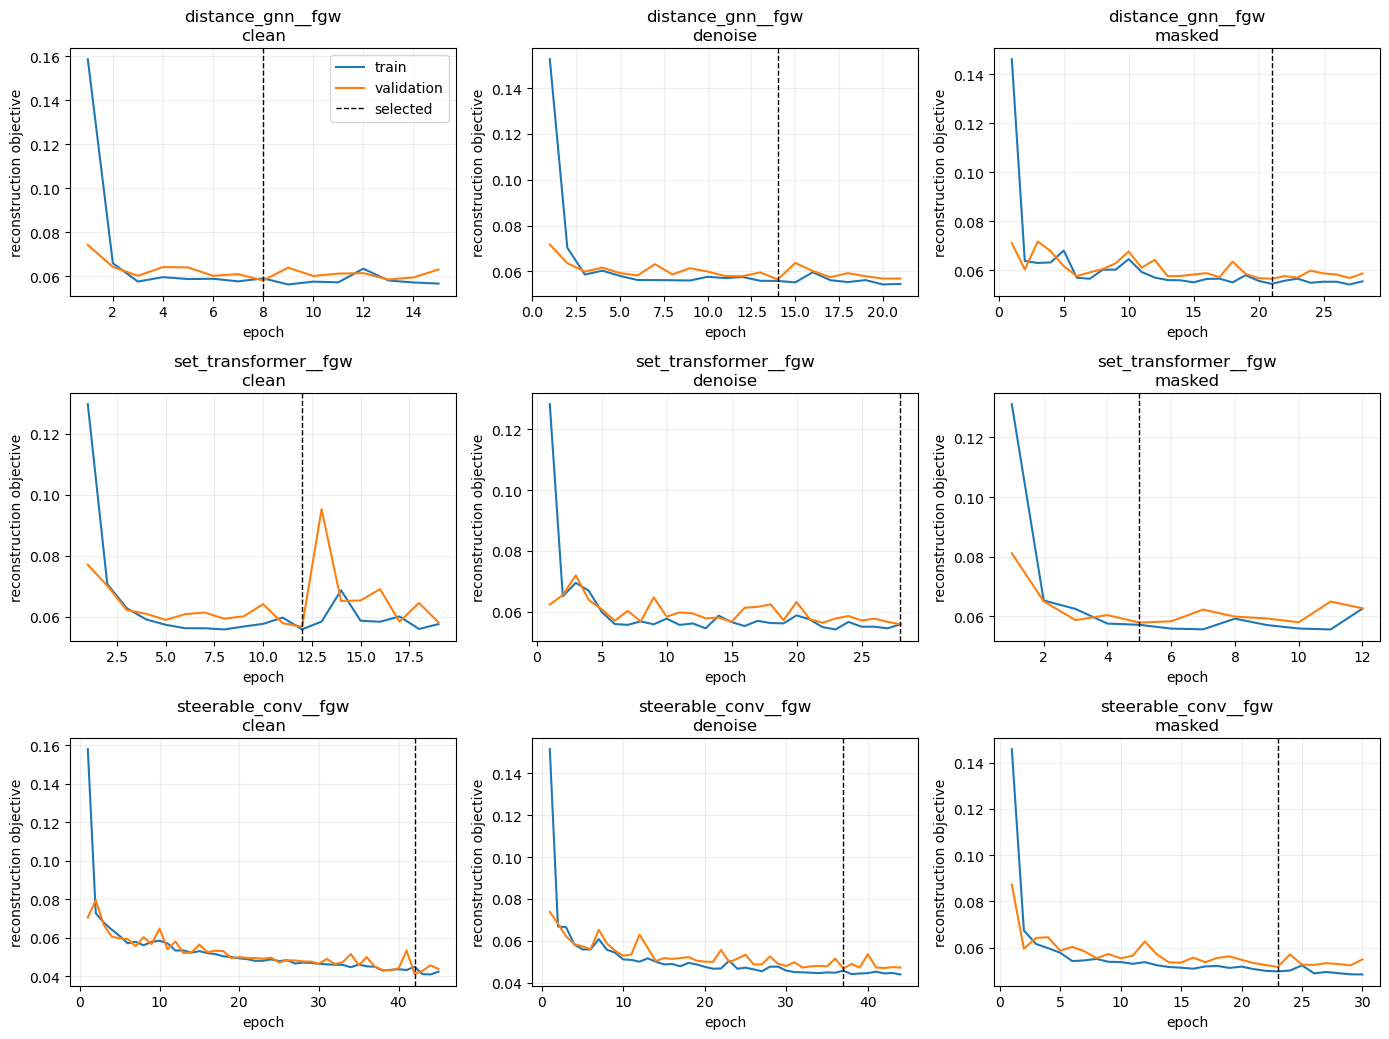

In [14]:
if RUN_MAIN_BENCHMARK:
    primary_available = [name for name in PRIMARY_EXPERIMENT_NAMES if (name, "clean") in artifacts]
    fig, axes = plt.subplots(len(primary_available), len(REGIMES), figsize=(14, 3.5 * len(primary_available)), squeeze=False)
    for row, name in enumerate(primary_available):
        for col, regime in enumerate(REGIMES):
            history = artifacts[(name, regime)]["history"]
            axes[row, col].plot(history["epoch"], history["train_reconstruction"], label="train")
            axes[row, col].plot(history["epoch"], history["val_reconstruction"], label="validation")
            axes[row, col].axvline(
                artifacts[(name, regime)]["best_epoch"], color="black", linestyle="--", linewidth=1,
                label="selected" if (row, col) == (0, 0) else None,
            )
            axes[row, col].set_title(f"{name}\n{regime}")
            axes[row, col].set_xlabel("epoch")
            axes[row, col].set_ylabel("reconstruction objective")
            axes[row, col].grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()


## 6. Common evaluation protocol

The common geometry metrics do not depend on the training loss:

- **FGW geometry:** alignment-free and set-invariant.
- **SO(3)+assignment RMSD:** Hungarian matching initialized from distance profiles, alternating with proper Kabsch rotation.
- **Pair-distance MAE:** sorted complete distance signatures.
- **Probe:** logistic regression on the full latent, fit on train+validation and evaluated once on test frames.
- **PCA:** fitted only on training latents and used only for visualization.
- Parameter count, best epoch, and wall-clock fit time.

Optimal alignment is evaluated on a capped test subset because it runs independently per cloud.


In [15]:
def kabsch_numpy(source, target):
    u, _, vh = np.linalg.svd(source.T @ target)
    correction = np.eye(3)
    correction[-1, -1] = np.sign(np.linalg.det(u @ vh))
    return u @ correction @ vh


def assignment_aligned_result_single(prediction, target, iterations=7, random_starts=3, seed=0):
    prediction, target = prediction[1:], target[1:]
    signature_p = np.sort(np.linalg.norm(prediction[:, None] - prediction[None, :], axis=-1), axis=-1)
    signature_t = np.sort(np.linalg.norm(target[:, None] - target[None, :], axis=-1), axis=-1)
    _, signature_assignment = linear_sum_assignment(
        np.linalg.norm(signature_p[:, None] - signature_t[None, :], axis=-1)
    )
    rng = np.random.default_rng(seed)
    starts = [signature_assignment] + [rng.permutation(len(target)) for _ in range(random_starts)]
    best = None
    for assignment in starts:
        for _ in range(iterations):
            rotation = kabsch_numpy(prediction, target[assignment])
            aligned = prediction @ rotation
            _, assignment = linear_sum_assignment(
                np.linalg.norm(aligned[:, None] - target[None, :], axis=-1)
            )
        rmsd = float(np.sqrt(np.mean(np.sum((aligned - target[assignment]) ** 2, axis=-1))))
        if best is None or rmsd < best[0]:
            best = (rmsd, aligned, target[assignment], assignment)
    center = np.zeros((1, 3), dtype=prediction.dtype)
    return best[0], np.concatenate([center, best[1]]), np.concatenate([center, best[2]]), best[3]


def pair_distance_mae_per_sample(prediction, target):
    prediction = torch.from_numpy(prediction)
    target = torch.from_numpy(target)
    dp, dt = torch.cdist(prediction, prediction), torch.cdist(target, target)
    i, j = torch.triu_indices(N_NODES, N_NODES, offset=1)
    return (dp[:, i, j].sort(dim=-1).values - dt[:, i, j].sort(dim=-1).values).abs().mean(dim=-1).numpy()


def common_fgw_per_sample(prediction, target, **kwargs):
    values = []
    with torch.no_grad():
        for start in range(0, len(prediction), BATCH_SIZE):
            p = torch.from_numpy(prediction[start:start + BATCH_SIZE]).to(DEVICE)
            t = torch.from_numpy(target[start:start + BATCH_SIZE]).to(DEVICE)
            values.append(fused_gromov_wasserstein_per_sample(p, t, **kwargs).cpu().numpy())
    return np.concatenate(values)


def balanced_test_indices(dataset, seed, max_samples=EVAL_MAX_SAMPLES):
    rng = np.random.default_rng(seed)
    split, labels = dataset["split"], dataset["labels"]
    candidates = [np.flatnonzero((split == "test") & (labels == LABEL_MAP[p])) for p in PHASES]
    per_phase = min(*(len(values) for values in candidates), max(1, max_samples // len(PHASES)))
    selected = [rng.choice(values, per_phase, replace=False) for values in candidates]
    return np.sort(np.concatenate(selected))


def latent_usage_diagnostics(latent_train):
    std = latent_train.std(axis=0)
    scaled = StandardScaler().fit_transform(latent_train)
    eigenvalues = np.maximum(np.linalg.eigvalsh(np.cov(scaled, rowvar=False)), 0)
    effective_rank = float(eigenvalues.sum() ** 2 / np.square(eigenvalues).sum())
    pca = PCA().fit(scaled)
    dimensions_90 = int(np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.90) + 1)
    return {
        "latent_effective_rank": effective_rank,
        "latent_dimensions_for_90pct": dimensions_90,
        "latent_min_std": float(std.min()),
        "latent_median_std": float(np.median(std)),
    }


def evaluate_artifact(artifact, dataset):
    split, labels = dataset["split"], dataset["labels"]
    fit, train, test = split != "test", split == "train", split == "test"
    clean_outputs = artifact["outputs_by_condition"]["clean"]
    clean_latent = clean_outputs["latent"]
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5_000, class_weight="balanced", random_state=artifact["seed"]),
    )
    probe.fit(clean_latent[fit], labels[fit])
    scaler = StandardScaler().fit(clean_latent[train])
    clean_scaled = scaler.transform(clean_latent)
    pca = PCA(n_components=2, random_state=artifact["seed"]).fit(clean_scaled[train])
    usage = latent_usage_diagnostics(clean_latent[train])
    test_indices = balanced_test_indices(dataset, artifact["seed"] + 1_000)
    physical_scale = dataset["coordinate_scale"]
    rows, phase_rows, derived = [], [], {}

    for condition_name, outputs in artifact["outputs_by_condition"].items():
        latent = outputs["latent"]
        label_prediction = probe.predict(latent[test])
        embedding = pca.transform(scaler.transform(latent))
        prediction = outputs["prediction"][test_indices]
        target = dataset["coordinates"][test_indices]
        fgw = common_fgw_per_sample(prediction, target)
        pair_mae = pair_distance_mae_per_sample(prediction, target)
        aligned_results = [
            assignment_aligned_result_single(p, t, seed=artifact["seed"] + i)
            for i, (p, t) in enumerate(zip(prediction, target))
        ]
        rmsd = np.asarray([item[0] for item in aligned_results])
        common = {
            "experiment": artifact["spec"]["name"], "study": artifact["spec"]["study"],
            "encoder": artifact["spec"]["encoder"], "training_loss": artifact["spec"]["loss"],
            "training_regime": artifact["regime"], "evaluation_condition": condition_name,
            "training_noise_sigma": artifact["regime_kwargs"].get("noise_sigma", np.nan),
            "training_mask_fraction": artifact["regime_kwargs"].get("mask_fraction", np.nan),
            "seed": artifact["seed"], "best_epoch": artifact["best_epoch"],
            "validation_objective": artifact["best_val_loss"],
            "test_FGW_geometry": float(fgw.mean()),
            "test_SO3_assignment_RMSD": float(rmsd.mean() * physical_scale),
            "test_pair_distance_MAE": float(pair_mae.mean() * physical_scale),
            "probe_balanced_accuracy": balanced_accuracy_score(labels[test], label_prediction),
            "probe_macro_F1": f1_score(labels[test], label_prediction, average="macro"),
            "PCA_2D_explained_variance": pca.explained_variance_ratio_.sum(),
            "parameters": artifact["parameters"], "runtime_seconds": artifact["runtime_seconds"],
            **usage,
        }
        rows.append(common)
        selected_labels = labels[test_indices]
        for phase in PHASES:
            phase_mask = selected_labels == LABEL_MAP[phase]
            phase_rows.append({
                "experiment": common["experiment"], "training_regime": common["training_regime"],
                "evaluation_condition": condition_name, "phase": phase,
                "FGW_geometry": float(fgw[phase_mask].mean()),
                "SO3_assignment_RMSD": float(rmsd[phase_mask].mean() * physical_scale),
                "pair_distance_MAE": float(pair_mae[phase_mask].mean() * physical_scale),
            })
        derived[condition_name] = {
            "probe": probe, "pca": pca, "scaler": scaler, "embedding": embedding,
            "label_prediction": label_prediction, "test_indices": test_indices,
            "aligned_results": aligned_results,
        }
    return rows, phase_rows, derived


evaluation_rows, phase_evaluation_rows, derived = [], [], {}
if RUN_MAIN_BENCHMARK:
    for key, artifact in artifacts.items():
        rows, phase_rows, extra = evaluate_artifact(artifact, dataset)
        evaluation_rows.extend(rows)
        phase_evaluation_rows.extend(phase_rows)
        derived[key] = extra
    results = pd.DataFrame(evaluation_rows)
    phase_results = pd.DataFrame(phase_evaluation_rows)
    display(results.sort_values(["study", "experiment", "training_regime", "evaluation_condition"]).reset_index(drop=True).round(5))
    display(phase_results.sort_values(["experiment", "training_regime", "evaluation_condition", "phase"]).reset_index(drop=True).round(5))


,experiment,study,encoder,training_loss,training_regime,evaluation_condition,training_noise_sigma,training_mask_fraction,seed,best_epoch,...,test_pair_distance_MAE,probe_balanced_accuracy,probe_macro_F1,PCA_2D_explained_variance,parameters,runtime_seconds,latent_effective_rank,latent_dimensions_for_90pct,latent_min_std,latent_median_std
0,distance_gnn__fgw,E1/E2,distance_gnn,fgw,clean,clean,NaN,NaN,42,8,...,0.08069,0.85903,0.85940,0.80960,73014,22.58307,2.73218,3,0.00019,0.00057
1,distance_gnn__fgw,E1/E2,distance_gnn,fgw,clean,mask_0.25,NaN,NaN,42,8,...,0.08114,0.33333,0.16395,0.80960,73014,22.58307,2.73218,3,0.00019,0.00057
2,distance_gnn__fgw,E1/E2,distance_gnn,fgw,clean,noise_0.05,NaN,NaN,42,8,...,0.08069,0.72534,0.71681,0.80960,73014,22.58307,2.73218,3,0.00019,0.00057
3,distance_gnn__fgw,E1/E2,distance_gnn,fgw,denoise,clean,NaN,NaN,42,14,...,0.08029,0.78173,0.78205,0.81313,73014,30.74455,2.75013,3,0.00018,0.00065
4,distance_gnn__fgw,E1/E2,distance_gnn,fgw,denoise,mask_0.25,NaN,NaN,42,14,...,0.08105,0.33333,0.17351,0.81313,73014,30.74455,2.75013,3,0.00018,0.00065
5,distance_gnn__fgw,E1/E2,distance_gnn,fgw,denoise,noise_0.05,NaN,NaN,42,14,...,0.08029,0.65322,0.63397,0.81313,73014,30.74455,2.75013,3,0.00018,0.00065
6,distance_gnn__fgw,E1/E2,distance_gnn,fgw,masked,clean,NaN,NaN,42,21,...,0.07951,0.85003,0.84969,0.86365,73014,40.38415,2.17345,3,0.00011,0.00044
7,distance_gnn__fgw,E1/E2,distance_gnn,fgw,masked,mask_0.25,NaN,NaN,42,21,...,0.07934,0.33333,0.16240,0.86365,73014,40.38415,2.17345,3,0.00011,0.00044
8,distance_gnn__fgw,E1/E2,distance_gnn,fgw,masked,noise_0.05,NaN,NaN,42,21,...,0.07951,0.74994,0.74523,0.86365,73014,40.38415,2.17345,3,0.00011,0.00044
9,distance_gnn__anchor,E2,distance_gnn,anchor_frame,clean,clean,NaN,NaN,42,6,...,0.14433,0.85833,0.85777,0.84287,73014,3.31690,2.32818,3,0.00012,0.00050


,experiment,training_regime,evaluation_condition,phase,FGW_geometry,SO3_assignment_RMSD,pair_distance_MAE
0,distance_gnn__anchor,clean,clean,fcc,0.08932,0.52226,0.13068
1,distance_gnn__anchor,clean,clean,hcp,0.09117,0.51438,0.12970
2,distance_gnn__anchor,clean,clean,liquid,0.16114,0.53458,0.17260
3,distance_gnn__anchor,clean,mask_0.25,fcc,0.08902,0.52247,0.12766
4,distance_gnn__anchor,clean,mask_0.25,hcp,0.09094,0.51480,0.12688
...,...,...,...,...,...,...,...
157,steerable_conv__fgw,masked,mask_0.25,hcp,0.04266,0.53078,0.06643
158,steerable_conv__fgw,masked,mask_0.25,liquid,0.07720,0.54953,0.05584
159,steerable_conv__fgw,masked,noise_0.05,fcc,0.05443,0.53806,0.10013
160,steerable_conv__fgw,masked,noise_0.05,hcp,0.06051,0.54930,0.11034


probe_balanced_accuracy  \
training_regime                                                  clean   
experiment                    training_loss                              
distance_gnn__anchor          anchor_frame                      0.8583   
distance_gnn__fgw             fgw                               0.8590   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch                   0.8743   
distance_gnn__sorted          sorted_distances                  0.8259   
set_transformer__fgw          fgw                               0.8732   
steerable_conv__fgw           fgw                               0.9087   

                                                               probe_macro_F1  \
training_regime                                denoise  masked          clean   
experiment                    training_loss                                     
distance_gnn__anchor          anchor_frame      0.8519  0.8568         0.8578   
distance_gnn__fgw             fgw               0.7817  0.8500         0.8594   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch   0.8792  0.9026         0.8737   
distance_gnn__sorted          sorted_distances  0.8539  0.8633         0.8257   
set_transformer__fgw          fgw               0.8962  0.8926         0.8726   
steerable_conv__fgw           fgw               0.9357  0.9699         0.9088   

                                                                \
training_regime                                denoise  masked   
experiment                    training_loss                      
distance_gnn__anchor          anchor_frame      0.8514  0.8543   
distance_gnn__fgw             fgw               0.7821  0.8497   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch   0.8789  0.9026   
distance_gnn__sorted          sorted_distances  0.8539  0.8628   
set_transformer__fgw          fgw               0.8960  0.8911   
steerable_conv__fgw           fgw               0.9358  0.9697   

                                               runtime_seconds            \
training_regime                                          clean   denoise   
experiment                    training_loss                                
distance_gnn__anchor          anchor_frame              3.3169    5.5837   
distance_gnn__fgw             fgw                      22.5831   30.7445   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch          31.5417   39.4415   
distance_gnn__sorted          sorted_distances          4.8427    2.4995   
set_transformer__fgw          fgw                      28.0080   40.6754   
steerable_conv__fgw           fgw                     211.1790  205.4719   

                                                         test_FGW_geometry  \
training_regime                                   masked             clean   
experiment                    training_loss                                  
distance_gnn__anchor          anchor_frame        6.7929            0.1139   
distance_gnn__fgw             fgw                40.3841            0.0594   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch    18.1209            0.1447   
distance_gnn__sorted          sorted_distances    3.1406            0.1101   
set_transformer__fgw          fgw                17.5515            0.0586   
steerable_conv__fgw           fgw               140.0889            0.0448   

                                                                \
training_regime                                denoise  masked   
experiment                    training_loss                      
distance_gnn__anchor          anchor_frame      0.1014  0.0913   
distance_gnn__fgw             fgw               0.0586  0.0585   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch   0.1374  0.1596   
distance_gnn__sorted          sorted_distances  0.1086  0.1182   
set_transformer__fgw          fgw               0.0576  0.0601   
steerable_conv__fgw           fgw               0.0484  0.0672   

                                               test_SO3_assignment_RMSD 

,experiment,training_regime,evaluation_condition,probe_change_from_clean,FGW_change_from_clean
0,distance_gnn__fgw,clean,clean,0.00000,0.00000
1,distance_gnn__fgw,clean,noise_0.05,-0.13369,-0.00000
2,distance_gnn__fgw,clean,mask_0.25,-0.52570,0.00013
3,distance_gnn__fgw,denoise,clean,0.00000,0.00000
4,distance_gnn__fgw,denoise,noise_0.05,-0.12851,-0.00000
5,distance_gnn__fgw,denoise,mask_0.25,-0.44839,0.00015
6,distance_gnn__fgw,masked,clean,0.00000,0.00000
7,distance_gnn__fgw,masked,noise_0.05,-0.10009,0.00000
8,distance_gnn__fgw,masked,mask_0.25,-0.51670,0.00003
9,distance_gnn__sorted,clean,clean,0.00000,0.00000


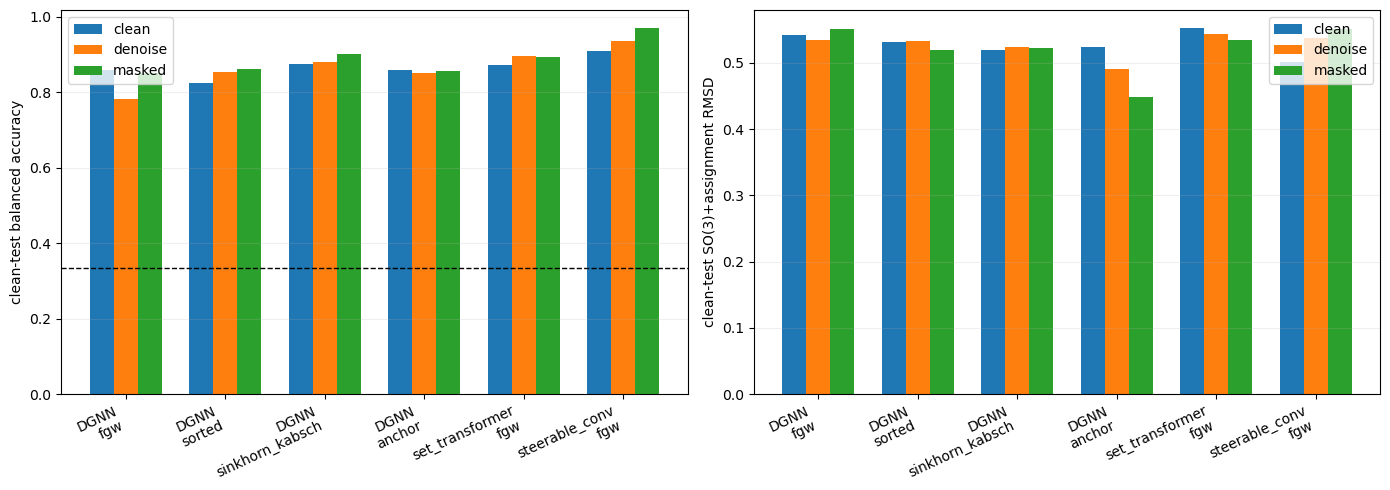

In [16]:
if RUN_MAIN_BENCHMARK:
    metric_columns = [
        "test_FGW_geometry", "test_SO3_assignment_RMSD", "test_pair_distance_MAE",
        "probe_balanced_accuracy", "probe_macro_F1", "runtime_seconds",
    ]
    clean_results = results[results["evaluation_condition"] == "clean"].copy()
    display(clean_results.pivot_table(
        index=["experiment", "training_loss"], columns="training_regime", values=metric_columns
    ).round(4))

    comparison = results.merge(
        clean_results[["experiment", "training_regime", "probe_balanced_accuracy", "test_FGW_geometry"]],
        on=["experiment", "training_regime"], suffixes=("", "_clean"),
    )
    comparison["probe_change_from_clean"] = (
        comparison["probe_balanced_accuracy"] - comparison["probe_balanced_accuracy_clean"]
    )
    comparison["FGW_change_from_clean"] = (
        comparison["test_FGW_geometry"] - comparison["test_FGW_geometry_clean"]
    )
    display(comparison[[
        "experiment", "training_regime", "evaluation_condition",
        "probe_change_from_clean", "FGW_change_from_clean",
    ]].round(5))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    names = list(dict.fromkeys(clean_results["experiment"]))
    width = 0.24
    x = np.arange(len(names))
    for offset, regime in enumerate(REGIMES):
        subset = clean_results.set_index(["experiment", "training_regime"])
        probe_values = [subset.loc[(name, regime), "probe_balanced_accuracy"] for name in names]
        rmsd_values = [subset.loc[(name, regime), "test_SO3_assignment_RMSD"] for name in names]
        axes[0].bar(x + (offset - 1) * width, probe_values, width, label=regime)
        axes[1].bar(x + (offset - 1) * width, rmsd_values, width, label=regime)
    axes[0].axhline(1/3, color="black", linestyle="--", linewidth=1)
    axes[0].set_ylabel("clean-test balanced accuracy")
    axes[1].set_ylabel("clean-test SO(3)+assignment RMSD")
    for ax in axes:
        ax.set_xticks(x, [name.replace("distance_gnn__", "DGNN\n").replace("__", "\n") for name in names], rotation=25, ha="right")
        ax.grid(axis="y", alpha=0.2)
        ax.legend()
    plt.tight_layout()
    plt.show()


## 7. Latent plots, invariance audit, and thermal-noise stability

The invariance audit transforms clean graphs without applying the training corruption. It reports maximum differences in the global latent and canonical decoder output. Both should remain near numerical tolerance.

Robustness is measured on the same phase-balanced held-out subset. In addition to raw cosine similarity, latent displacement is standardized by the natural training-set variation of each dimension. A probe fitted on clean train+validation latents is then evaluated under noise and masking, and nearest-neighbor retention measures whether local latent identity is preserved.


In [17]:
def invariant_model_audit(artifact, dataset):
    model = artifact["model"].to(DEVICE).eval()
    x = torch.from_numpy(dataset["coordinates"][:8]).to(DEVICE)
    observed = torch.ones(len(x), N_NODES, 1, device=DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(MAIN_SEED + 700)
    transformed = permute_neighbors(x, generator)
    rotations = random_rotation_matrices(len(x), DEVICE, generator)
    transformed = transformed @ rotations.transpose(-1, -2)
    with torch.no_grad():
        output, latent = model(x, observed)
        transformed_output, transformed_latent = model(transformed, observed)
    model.cpu()
    return {
        "experiment": artifact["spec"]["name"],
        "training_regime": artifact["regime"],
        "latent_max_abs_difference": (latent - transformed_latent).abs().max().item(),
        "decoder_max_abs_difference": (output - transformed_output).abs().max().item(),
    }


def corruption_stability(artifact, dataset):
    model = artifact["model"].to(DEVICE).eval()
    indices = balanced_test_indices(dataset, artifact["seed"] + 2_000)
    clean = torch.from_numpy(dataset["coordinates"][indices]).to(DEVICE)
    observed = torch.ones(len(clean), N_NODES, 1, device=DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(MAIN_SEED + 800)
    clean_latent_all = artifact["outputs_by_condition"]["clean"]["latent"]
    train = dataset["split"] == "train"
    fit = dataset["split"] != "test"
    scaler = StandardScaler().fit(clean_latent_all[train])
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5_000, class_weight="balanced", random_state=artifact["seed"]),
    ).fit(clean_latent_all[fit], dataset["labels"][fit])
    with torch.no_grad():
        reference = model.encoder(clean, observed)
        rows = []
        conditions = (
            [("noise", sigma, "denoise", {"noise_sigma": sigma}) for sigma in NOISE_LEVELS]
            + [("mask", fraction, "masked", {"mask_fraction": fraction}) for fraction in MASK_LEVELS]
        )
        reference_np = reference.cpu().numpy()
        reference_scaled = scaler.transform(reference_np)
        for corruption, level, regime, kwargs in conditions:
            inputs, condition_observed, _ = prepare_regime_batch(
                clean, regime, generator, augment=False, **kwargs
            )
            latent = model.encoder(inputs, condition_observed)
            latent_np = latent.cpu().numpy()
            latent_scaled = scaler.transform(latent_np)
            distances = np.square(latent_scaled[:, None] - reference_scaled[None]).sum(axis=-1)
            nearest = distances.argmin(axis=1)
            rows.append({
                "experiment": artifact["spec"]["name"], "training_regime": artifact["regime"],
                "corruption": corruption, "level": level,
                "latent_cosine_similarity": F.cosine_similarity(reference, latent, dim=-1).mean().item(),
                "standardized_latent_shift": float(np.sqrt(np.square(latent_scaled - reference_scaled).mean(axis=1)).mean()),
                "nearest_neighbor_retention": float(np.mean(nearest == np.arange(len(nearest)))),
                "probe_balanced_accuracy": balanced_accuracy_score(
                    dataset["labels"][indices], probe.predict(latent_np)
                ),
            })
    model.cpu()
    return rows


invariance_table = pd.DataFrame()
robustness_table = pd.DataFrame()
if RUN_MAIN_BENCHMARK:
    invariance_table = pd.DataFrame([invariant_model_audit(a, dataset) for a in artifacts.values()])
    robustness_table = pd.DataFrame([
        row for artifact in artifacts.values() for row in corruption_stability(artifact, dataset)
    ])
    display(invariance_table.sort_values(["experiment", "training_regime"]).style.format({
        "latent_max_abs_difference": "{:.3e}", "decoder_max_abs_difference": "{:.3e}"
    }))
    display(robustness_table.sort_values(
        ["experiment", "training_regime", "corruption", "level"]
    ).reset_index(drop=True).round(5))


,experiment,training_regime,latent_max_abs_difference,decoder_max_abs_difference
9,distance_gnn__anchor,clean,1.192e-07,3.576e-07
10,distance_gnn__anchor,denoise,1.788e-07,2.384e-07
11,distance_gnn__anchor,masked,2.384e-07,2.384e-07
0,distance_gnn__fgw,clean,2.384e-07,2.384e-07
1,distance_gnn__fgw,denoise,2.384e-07,2.980e-07
2,distance_gnn__fgw,masked,2.384e-07,2.384e-07
6,distance_gnn__sinkhorn_kabsch,clean,2.384e-07,2.384e-07
7,distance_gnn__sinkhorn_kabsch,denoise,4.768e-07,2.384e-07
8,distance_gnn__sinkhorn_kabsch,masked,2.384e-07,2.384e-07
3,distance_gnn__sorted,clean,2.384e-07,2.384e-07


,experiment,training_regime,corruption,level,latent_cosine_similarity,standardized_latent_shift,nearest_neighbor_retention,probe_balanced_accuracy
0,distance_gnn__anchor,clean,mask,0.10,0.99926,78.41301,0.00201,0.33333
1,distance_gnn__anchor,clean,mask,0.20,0.99923,81.99757,0.00201,0.33333
2,distance_gnn__anchor,clean,mask,0.30,0.99921,84.17112,0.00201,0.33333
3,distance_gnn__anchor,clean,noise,0.01,1.00000,0.22071,0.51406,0.85341
4,distance_gnn__anchor,clean,noise,0.03,1.00000,0.65809,0.08233,0.82731
...,...,...,...,...,...,...,...,...
121,steerable_conv__fgw,masked,mask,0.30,0.93943,2.31266,0.00201,0.46988
122,steerable_conv__fgw,masked,noise,0.01,0.99997,0.05358,0.99598,0.96586
123,steerable_conv__fgw,masked,noise,0.03,0.99970,0.16369,0.60040,0.94578
124,steerable_conv__fgw,masked,noise,0.05,0.99895,0.30025,0.25703,0.89157


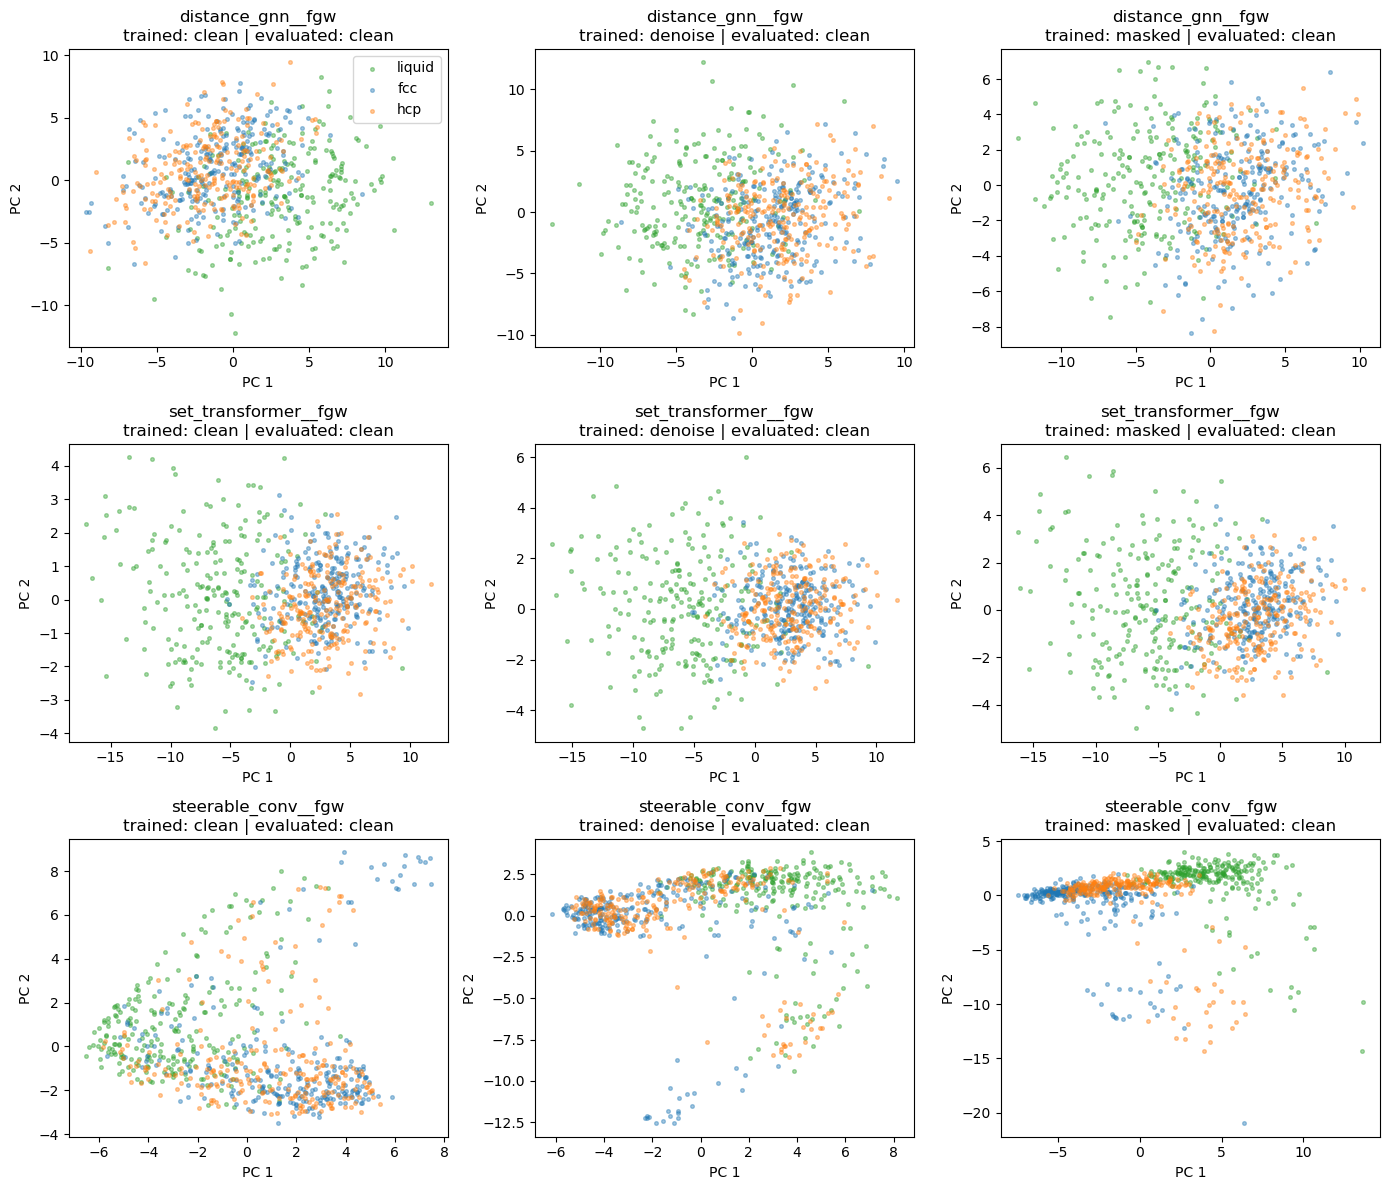

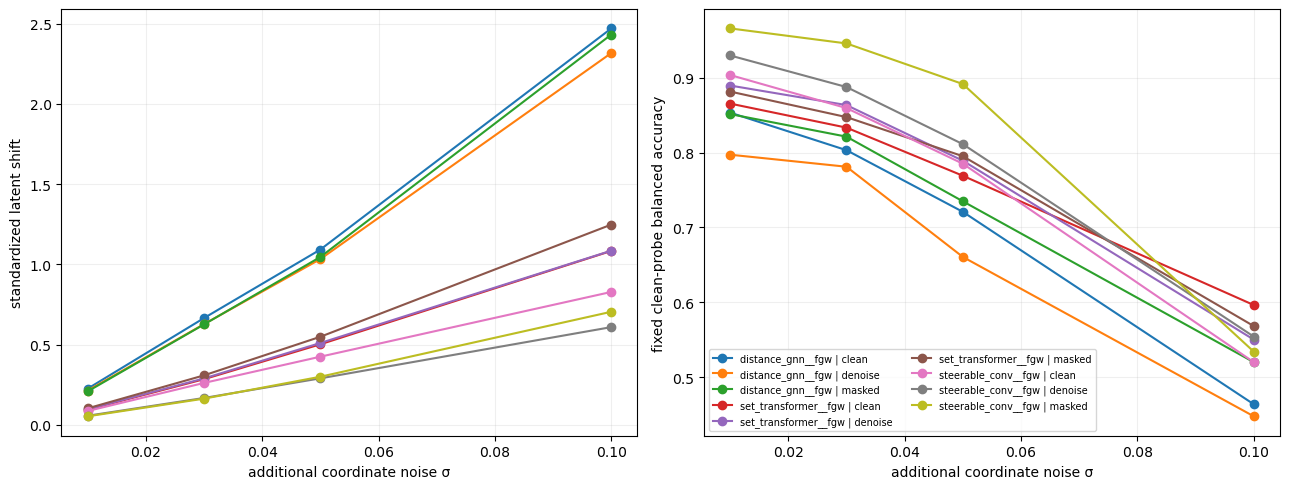

In [18]:
if RUN_MAIN_BENCHMARK:
    primary_names = ("distance_gnn__fgw", "set_transformer__fgw", "steerable_conv__fgw")
    available = [name for name in primary_names if (name, "denoise") in artifacts]
    fig, axes = plt.subplots(len(available), len(REGIMES), figsize=(14, 4 * len(available)), squeeze=False)
    test = dataset["split"] == "test"
    for row, name in enumerate(available):
        for col, regime in enumerate(REGIMES):
            embedding = derived[(name, regime)]["clean"]["embedding"]
            ax = axes[row, col]
            for phase in PHASES:
                mask = test & (dataset["labels"] == LABEL_MAP[phase])
                ax.scatter(embedding[mask, 0], embedding[mask, 1], s=7, alpha=0.4,
                           color=LABEL_COLORS[phase], label=phase)
            ax.set_title(f"{name}\ntrained: {regime} | evaluated: clean")
            ax.set_xlabel("PC 1")
            ax.set_ylabel("PC 2")
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    noise_only = robustness_table[robustness_table["corruption"] == "noise"]
    for (experiment, regime), group in noise_only.groupby(["experiment", "training_regime"]):
        if experiment in available:
            label = f"{experiment} | {regime}"
            axes[0].plot(group["level"], group["standardized_latent_shift"], marker="o", label=label)
            axes[1].plot(group["level"], group["probe_balanced_accuracy"], marker="o", label=label)
    axes[0].set(xlabel="additional coordinate noise σ", ylabel="standardized latent shift")
    axes[1].set(xlabel="additional coordinate noise σ", ylabel="fixed clean-probe balanced accuracy")
    for ax in axes:
        ax.grid(alpha=0.2)
    axes[1].legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


## 8. What the decoder actually reconstructs

Aggregate losses can hide prototype collapse or homometric point sets. The following diagnostics therefore show median-error aligned clouds, per-phase geometry, confusion matrices, and complete radial/pair-distance distributions. Alignment is used only for visualization and the reported aligned RMSD; invariant losses remain the training objective.


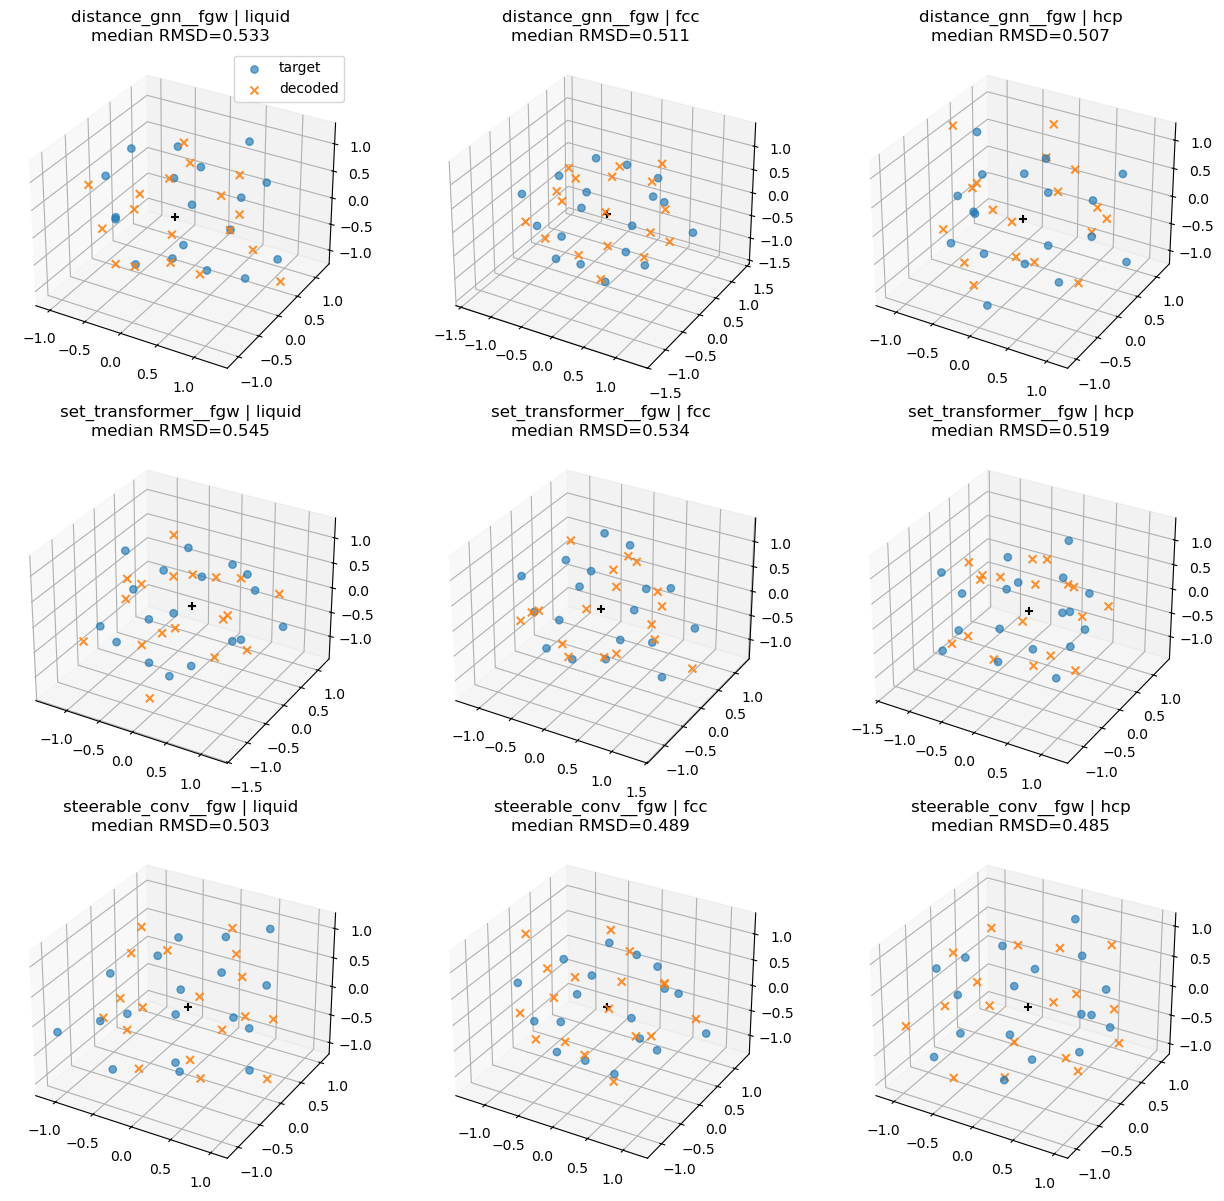

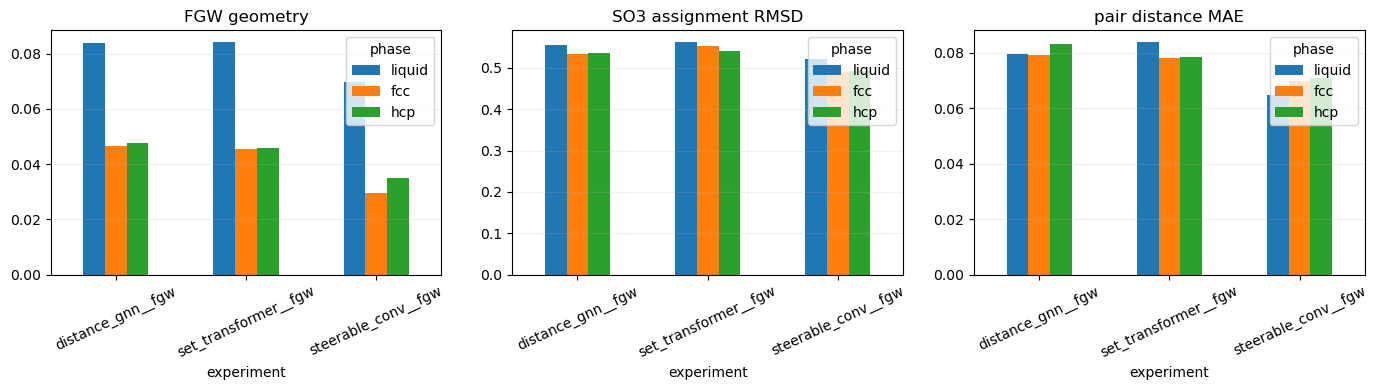

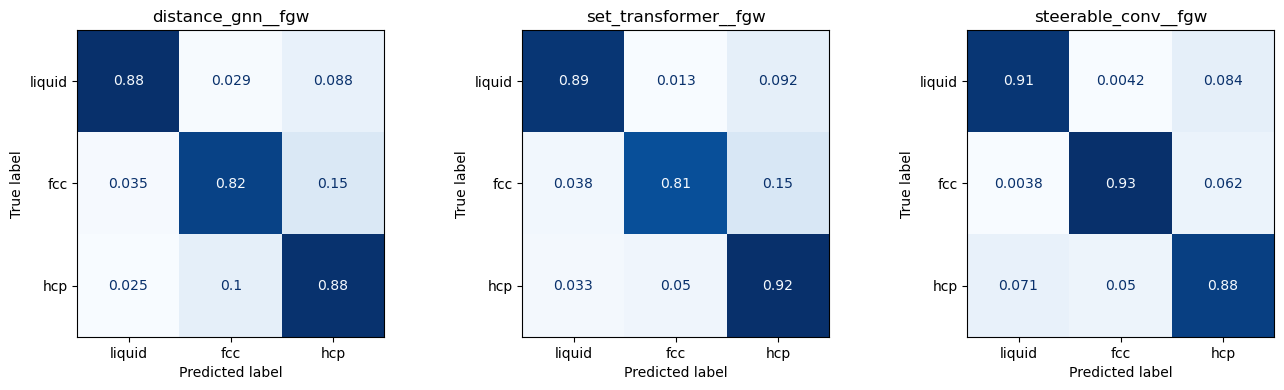

In [19]:
def set_equal_3d_axes(ax, points):
    center = points.mean(axis=0)
    radius = max(1e-3, np.abs(points - center).max())
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)


if RUN_MAIN_BENCHMARK:
    primary_available = [name for name in PRIMARY_EXPERIMENT_NAMES if (name, "clean") in artifacts]
    fig = plt.figure(figsize=(13, 4 * len(primary_available)))
    for row, name in enumerate(primary_available):
        key = (name, "clean")
        info = derived[key]["clean"]
        indices = info["test_indices"]
        labels = dataset["labels"][indices]
        rmsds = np.asarray([item[0] for item in info["aligned_results"]])
        for col, phase in enumerate(PHASES):
            local = np.flatnonzero(labels == LABEL_MAP[phase])
            chosen = local[np.argsort(rmsds[local])[len(local) // 2]]
            _, aligned_prediction, aligned_target, _ = info["aligned_results"][chosen]
            ax = fig.add_subplot(len(primary_available), len(PHASES), row * len(PHASES) + col + 1, projection="3d")
            ax.scatter(*aligned_target[1:].T, s=28, marker="o", alpha=0.65, label="target")
            ax.scatter(*aligned_prediction[1:].T, s=32, marker="x", alpha=0.85, label="decoded")
            ax.scatter(0, 0, 0, color="black", s=40, marker="+")
            set_equal_3d_axes(ax, np.concatenate([aligned_target, aligned_prediction]))
            ax.set_title(f"{name} | {phase}\nmedian RMSD={rmsds[chosen] * dataset['coordinate_scale']:.3f}")
            if row == 0 and col == 0:
                ax.legend()
    plt.tight_layout()
    plt.show()

    clean_phase = phase_results[
        phase_results["experiment"].isin(primary_available)
        & (phase_results["training_regime"] == "clean")
        & (phase_results["evaluation_condition"] == "clean")
    ]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, ("FGW_geometry", "SO3_assignment_RMSD", "pair_distance_MAE")):
        pivot = clean_phase.pivot(index="experiment", columns="phase", values=metric).reindex(columns=PHASES)
        pivot.plot.bar(ax=ax)
        ax.set_title(metric.replace("_", " "))
        ax.grid(axis="y", alpha=0.2)
        ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, len(primary_available), figsize=(4.5 * len(primary_available), 4))
    axes = np.atleast_1d(axes)
    test = dataset["split"] == "test"
    for ax, name in zip(axes, primary_available):
        predictions = derived[(name, "clean")]["clean"]["label_prediction"]
        ConfusionMatrixDisplay.from_predictions(
            dataset["labels"][test], predictions, display_labels=PHASES,
            normalize="true", cmap="Blues", colorbar=False, ax=ax,
        )
        ax.set_title(name)
    plt.tight_layout()
    plt.show()


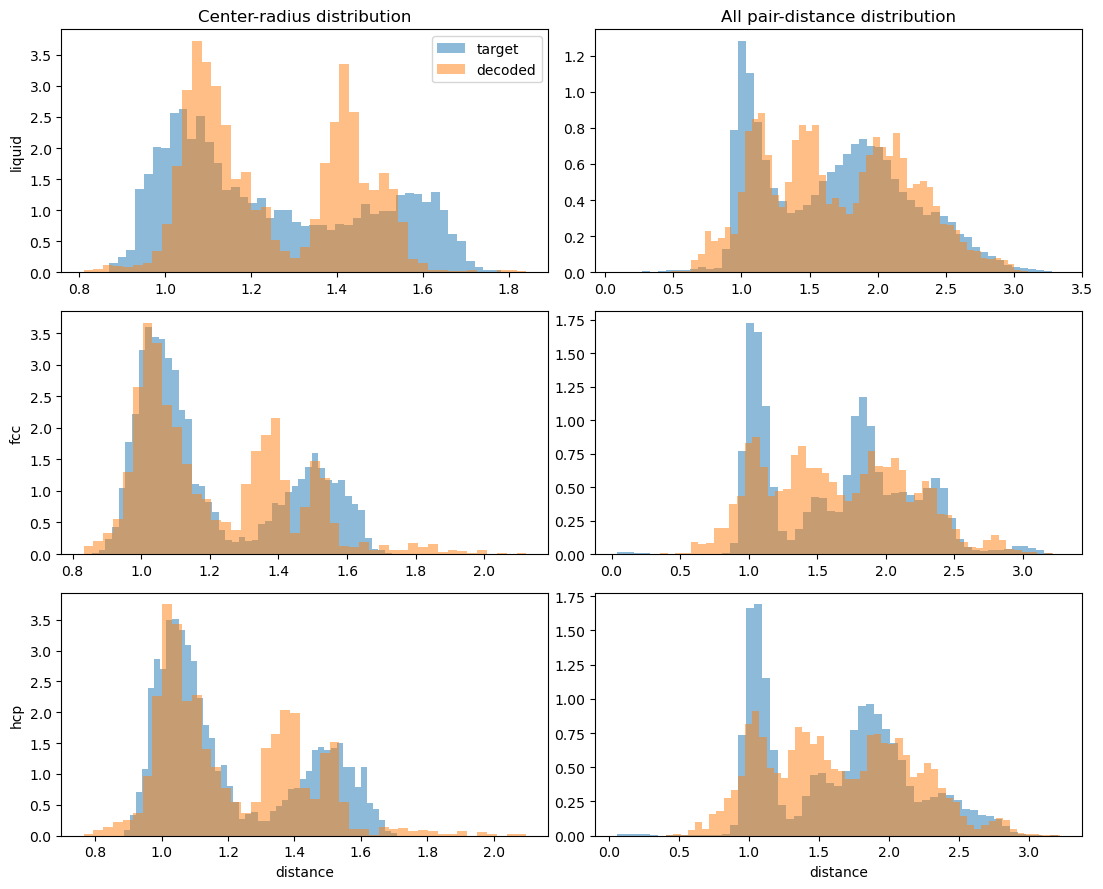

In [20]:
if RUN_MAIN_BENCHMARK and ("steerable_conv__fgw", "clean") in artifacts:
    name, training_regime = "steerable_conv__fgw", "clean"
    outputs = artifacts[(name, training_regime)]["outputs_by_condition"]["clean"]
    indices = balanced_test_indices(dataset, MAIN_SEED + 3_000)
    prediction = outputs["prediction"][indices] * dataset["coordinate_scale"]
    target = dataset["coordinates"][indices] * dataset["coordinate_scale"]
    labels = dataset["labels"][indices]
    i, j = np.triu_indices(N_NODES, k=1)
    fig, axes = plt.subplots(len(PHASES), 2, figsize=(11, 9))
    for row, phase in enumerate(PHASES):
        mask = labels == LABEL_MAP[phase]
        target_radii = np.linalg.norm(target[mask, 1:], axis=-1).ravel()
        predicted_radii = np.linalg.norm(prediction[mask, 1:], axis=-1).ravel()
        target_pairs = np.linalg.norm(target[mask, :, None] - target[mask, None, :], axis=-1)[:, i, j].ravel()
        predicted_pairs = np.linalg.norm(prediction[mask, :, None] - prediction[mask, None, :], axis=-1)[:, i, j].ravel()
        axes[row, 0].hist(target_radii, bins=45, density=True, alpha=0.5, label="target")
        axes[row, 0].hist(predicted_radii, bins=45, density=True, alpha=0.5, label="decoded")
        axes[row, 1].hist(target_pairs, bins=55, density=True, alpha=0.5, label="target")
        axes[row, 1].hist(predicted_pairs, bins=55, density=True, alpha=0.5, label="decoded")
        axes[row, 0].set_ylabel(phase)
    axes[0, 0].set_title("Center-radius distribution")
    axes[0, 1].set_title("All pair-distance distribution")
    axes[0, 0].legend()
    for ax in axes[-1]:
        ax.set_xlabel("distance")
    plt.tight_layout()
    plt.show()


## 9. Prioritized follow-up experiments

The expensive follow-ups are implemented but opt-in:

- Five seeds for the three primary FGW encoders and all training regimes: 45 fits rather than repeating every loss baseline.
- Global latent widths 16, 32, and 64 for the three primary clean models: 9 fits.
- Steerable denoising strengths 0.01–0.10 and masking fractions 0.10–0.30.
- Variance/covariance regularization for the primary clean encoders.
- A wider Set Transformer (hidden width 72) for an approximately parameter-matched comparison with E4.

FGW numerical sensitivity and learned steerable radial-filter magnitudes are inexpensive and run with the main analysis.


,temperature,outer_steps,mean_FGW,std_FGW
0,0.04,2,0.046510,0.025029
1,0.04,4,0.221207,0.042180
2,0.04,8,0.130066,0.033271
3,0.08,2,0.021100,0.017654
4,0.08,4,0.044531,0.033745
5,0.08,8,0.197504,0.044731
6,0.16,2,0.009641,0.010890
7,0.16,4,0.018179,0.018376
8,0.16,8,0.020936,0.021072


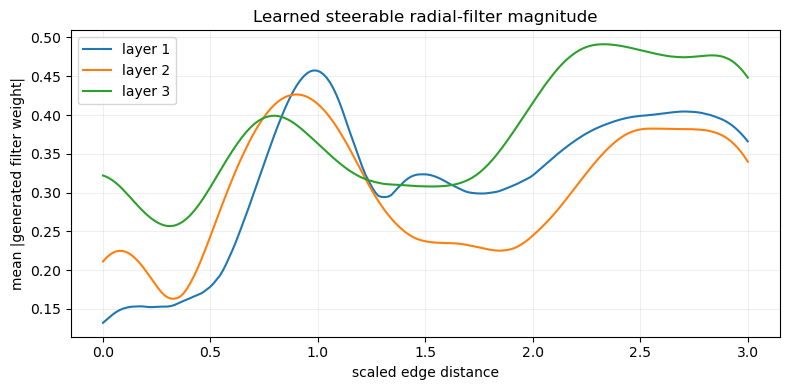

In [21]:
primary_specs = [spec for spec in EXPERIMENT_SPECS if spec["name"] in PRIMARY_EXPERIMENT_NAMES]

if RUN_PRIMARY_FIVE_SEED_ROBUSTNESS:
    robustness_frames = [results[results["experiment"].isin(PRIMARY_EXPERIMENT_NAMES)]]
    for seed in ROBUSTNESS_SEEDS:
        if seed == MAIN_SEED:
            continue
        seeded_dataset = prepare_dataset(seed)
        seeded_artifacts = run_experiment_matrix(
            seeded_dataset, seed, keep_artifacts=True, specs=primary_specs
        )
        seeded_rows = []
        for artifact in seeded_artifacts.values():
            rows, _, _ = evaluate_artifact(artifact, seeded_dataset)
            seeded_rows.extend(rows)
        robustness_frames.append(pd.DataFrame(seeded_rows))
        del seeded_artifacts
        gc.collect()
    robustness_results = pd.concat(robustness_frames, ignore_index=True)
    display(
        robustness_results.groupby(["experiment", "training_regime", "evaluation_condition"])[[
            "test_FGW_geometry", "test_SO3_assignment_RMSD", "test_pair_distance_MAE",
            "probe_balanced_accuracy", "probe_macro_F1",
        ]].agg(["mean", "std", "min", "max"]).round(4)
    )

if RUN_LATENT_WIDTH_ABLATION:
    width_rows = []
    for latent_dim in LATENT_DIMENSIONS:
        width_specs = [{**spec, "latent_dim": latent_dim} for spec in primary_specs]
        width_artifacts = run_experiment_matrix(
            dataset, MAIN_SEED, keep_artifacts=True, specs=width_specs, regimes=("clean",)
        )
        for artifact in width_artifacts.values():
            rows, _, _ = evaluate_artifact(artifact, dataset)
            for row in rows:
                row["latent_dim"] = latent_dim
            width_rows.extend(rows)
    width_results = pd.DataFrame(width_rows)
    display(width_results[width_results["evaluation_condition"] == "clean"].pivot_table(
        index="experiment", columns="latent_dim",
        values=["test_FGW_geometry", "test_SO3_assignment_RMSD", "probe_balanced_accuracy", "latent_effective_rank"],
    ).round(4))

if RUN_CORRUPTION_STRENGTH_ABLATION:
    steerable_spec = next(spec for spec in primary_specs if spec["encoder"] == "steerable_conv")
    strength_rows = []
    strength_artifacts = []
    for sigma in NOISE_LEVELS:
        artifact = train_one(steerable_spec, "denoise", dataset, MAIN_SEED, {"noise_sigma": sigma})
        strength_artifacts.append(artifact)
    for fraction in MASK_LEVELS:
        artifact = train_one(steerable_spec, "masked", dataset, MAIN_SEED, {"mask_fraction": fraction})
        strength_artifacts.append(artifact)
    for artifact in strength_artifacts:
        rows, _, _ = evaluate_artifact(artifact, dataset)
        strength_rows.extend(rows)
    corruption_strength_results = pd.DataFrame(strength_rows)
    display(corruption_strength_results.round(4))

if RUN_LATENT_REGULARIZATION_ABLATION:
    regularized_specs = [
        {**spec, "name": spec["name"] + "__latent_reg", "latent_regularization": 1e-3}
        for spec in primary_specs
    ]
    regularized_artifacts = run_experiment_matrix(
        dataset, MAIN_SEED, keep_artifacts=True, specs=regularized_specs, regimes=("clean",)
    )
    regularized_rows = []
    for artifact in regularized_artifacts.values():
        rows, _, _ = evaluate_artifact(artifact, dataset)
        regularized_rows.extend(rows)
    regularized_results = pd.DataFrame(regularized_rows)
    display(regularized_results[regularized_results["evaluation_condition"] == "clean"].round(4))

if RUN_PARAMETER_MATCHED_ABLATION:
    base_transformer = next(spec for spec in primary_specs if spec["encoder"] == "set_transformer")
    matched_spec = {
        **base_transformer,
        "name": "set_transformer__fgw__wide72",
        "encoder_kwargs": {"hidden_dim": 72},
    }
    matched_artifacts = run_experiment_matrix(
        dataset, MAIN_SEED, keep_artifacts=True, specs=[matched_spec], regimes=REGIMES
    )
    matched_rows = []
    for artifact in matched_artifacts.values():
        rows, _, _ = evaluate_artifact(artifact, dataset)
        matched_rows.extend(rows)
    parameter_matched_results = pd.DataFrame(matched_rows)
    display(parameter_matched_results.round(4))

if RUN_MAIN_BENCHMARK and ("steerable_conv__fgw", "clean") in artifacts:
    artifact = artifacts[("steerable_conv__fgw", "clean")]
    indices = balanced_test_indices(dataset, MAIN_SEED + 4_000, max_samples=96)
    prediction = artifact["outputs_by_condition"]["clean"]["prediction"][indices]
    target = dataset["coordinates"][indices]
    sensitivity_rows = []
    for temperature in (0.04, 0.08, 0.16):
        for outer_steps in (2, 4, 8):
            values = common_fgw_per_sample(
                prediction, target, temperature=temperature,
                outer_steps=outer_steps, sinkhorn_steps=max(12, SINKHORN_STEPS),
            )
            sensitivity_rows.append({
                "temperature": temperature, "outer_steps": outer_steps,
                "mean_FGW": values.mean(), "std_FGW": values.std(),
            })
    display(pd.DataFrame(sensitivity_rows).round(6))

    model = artifact["model"]
    radii = torch.linspace(0, 3, 200).view(-1, 1)
    fig, ax = plt.subplots(figsize=(8, 4))
    with torch.no_grad():
        for layer_index, layer in enumerate(model.encoder.layers):
            weights = layer.radial(layer.rbf(radii)).abs().mean(dim=-1).numpy()
            ax.plot(radii.squeeze().numpy(), weights, label=f"layer {layer_index + 1}")
    ax.set(xlabel="scaled edge distance", ylabel="mean |generated filter weight|",
           title="Learned steerable radial-filter magnitude")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()


## 10. Decision rules

Do not select a model from its PCA appearance. Use the following order:

1. Reject any model whose invariance audit is not near numerical tolerance.
2. Compare FGW, aligned RMSD, and pair-distance MAE within each corruption regime.
3. Prefer denoising/masking only when they improve noise stability or held-out probe quality without a large geometry penalty.
4. Compare E1, E3, and E4 under the same FGW loss to isolate the encoder.
5. Use E2 only to select the reconstruction loss; anchor instability under thermal noise is itself an important negative result.
6. Require the five-seed distribution before claiming one representation is better.

### Important limitations

- A canonical set decoder does not preserve particle identities; that is intentional for identical particles.
- FGW is entropically regularized and approximate. Sinkhorn temperature and iteration-count sensitivity should be checked for the winning model.
- Distance-only objectives identify generic point clouds up to rigid motion and reflection, but homometric exceptions exist.
- The E4 invariant contraction uses learned equivariant features, not handcrafted order parameters, but it still encodes a symmetry prior through irreducible representations.
- Masking coordinates by zero is safe only because an explicit observed-mask feature is supplied.


## 11. Fully equivariant global-latent autoencoders

The preceding matrix deliberately contracted every non-scalar feature to an
invariant before decoding.  This follow-up keeps a compact *global* latent,
but lets that latent carry SO(3)/O(3) irreducible representations.  The
reconstruction contract is now

$$E(PXR^T)=\rho(R)E(X), \qquad D(\rho(R)z)=D(z)R^T,$$

where the decoded neighbors are still an unordered set.  Consequently the
primary loss is a direct coordinate optimal-transport loss: no Kabsch
alignment, canonical frame, pair-distance surrogate, or FGW rotation removal
is used.

Four clean-autoencoding prototypes are compared:

1. **Tensor-field point AE** — the existing steerable point convolutions,
   equivariant global pooling, and a tensor-product point decoder.
2. **Holographic Fourier AE** — radial/spherical-harmonic coefficients,
   Clebsch–Gordan-style tensor-product bottleneck, coefficient reconstruction,
   and an equivariant point readout.
3. **Vector-neuron PointNet AE** — graph-free vector features, invariant
   attention pooling, and a vector-neuron point decoder.
4. **Spectral spherical CNN AE** — learned spectral convolutions and global
   invariant gates in spherical-Fourier space, with coefficient and point
   decoders.

All four produce 18 oriented neighbor vectors and are evaluated by the same
direct assignment RMSD, pair-distance MAE, spherical-spectrum error, invariant
latent phase probe, and explicit equivariance audit.  Models 2 and 4 have an
additional native coefficient-reconstruction objective.



In [22]:
# Configuration for the clean equivariant comparison.
RUN_EQUIVARIANT_AUTOENCODERS = True
EQ_SEED = MAIN_SEED + 100
EQ_BATCH_SIZE = 96
EQ_MAX_EPOCHS = 32
EQ_PATIENCE = 6
EQ_LEARNING_RATE = 2e-3
EQ_WEIGHT_DECAY = 1e-5
EQ_GRAD_CLIP = 5.0
EQ_SINKHORN_TEMPERATURE = 0.05
EQ_SINKHORN_STEPS = 20
EQ_AUX_COEFFICIENT_WEIGHT = 0.10
EQ_EVAL_MAX_SAMPLES = 498

EQ_RADIAL_CHANNELS = 4
EQ_LMAX = 6
EQ_RADIAL_CUTOFF = 3.0
EQ_POINT_HIDDEN_IRREPS = "20x0e + 8x1o + 4x2e + 2x3o + 2x4e"
EQ_POINT_LATENT_IRREPS = "12x0e + 8x1o + 4x2e + 2x3o + 2x4e"
EQ_SPECTRAL_LATENT_IRREPS = (
    "8x0e + 4x1o + 4x2e + 2x3o + 2x4e + 1x5o + 1x6e"
)
EQ_VECTOR_CHANNELS = 32
EQ_MAX_BATCHES = None

if os.environ.get("AE_EQUIVARIANT_SMOKE_TEST") == "1":
    EQ_MAX_EPOCHS = 1
    EQ_PATIENCE = 1
    EQ_MAX_BATCHES = 2
    EQ_EVAL_MAX_SAMPLES = 36

if not E3NN_AVAILABLE:
    raise RuntimeError("The fully equivariant comparison requires e3nn")


def parity_for_degree(degree):
    return "e" if degree % 2 == 0 else "o"


def spherical_coefficient_irreps(n_radial=EQ_RADIAL_CHANNELS, lmax=EQ_LMAX):
    return o3.Irreps(" + ".join(
        f"{n_radial}x{degree}{parity_for_degree(degree)}"
        for degree in range(lmax + 1)
    ))


class SphericalNeighborExpansion(nn.Module):
    """Permutation-invariant radial × spherical-harmonic neighbor density."""

    def __init__(self, n_radial=EQ_RADIAL_CHANNELS, lmax=EQ_LMAX, cutoff=EQ_RADIAL_CUTOFF):
        super().__init__()
        self.n_radial = n_radial
        self.lmax = lmax
        self.cutoff = cutoff
        self.irreps = spherical_coefficient_irreps(n_radial, lmax)
        self.register_buffer("centers", torch.linspace(0.35, cutoff, n_radial))
        spacing = float((cutoff - 0.35) / max(1, n_radial - 1))
        self.gamma = 1.0 / max(spacing, 1e-3) ** 2

    def forward(self, coordinates):
        points = coordinates[:, 1:]
        radii = points.norm(dim=-1, keepdim=True)
        radial = torch.exp(-self.gamma * (radii - self.centers).square())
        blocks = []
        for degree in range(self.lmax + 1):
            harmonics = o3.spherical_harmonics(
                degree, points, normalize=True, normalization="component"
            )
            block = torch.einsum("bnr,bnm->brm", radial, harmonics) / N_NEIGHBORS
            blocks.append(block.flatten(1))
        return torch.cat(blocks, dim=-1)

    def invariant_features(self, coefficients):
        return invariant_features_from_irreps(coefficients, self.irreps)

    def angular_power(self, coefficients):
        powers = []
        for (multiplicity, irrep), slc in zip(self.irreps, self.irreps.slices()):
            block = coefficients[:, slc].reshape(len(coefficients), multiplicity, irrep.dim)
            powers.append(block.square().sum(dim=-1).mean(dim=-1).clamp_min(0).sqrt())
        return torch.stack(powers, dim=-1)


def invariant_features_from_irreps(values, irreps):
    features = []
    for (multiplicity, irrep), slc in zip(irreps, irreps.slices()):
        block = values[:, slc].reshape(len(values), multiplicity, irrep.dim)
        if irrep.l == 0:
            features.append(block.squeeze(-1))
        else:
            features.append(block.square().sum(dim=-1).clamp_min(1e-12).sqrt())
    return torch.cat(features, dim=-1)


def rotate_irrep_features(values, irreps, rotations):
    matrices = irreps.D_from_matrix(rotations).to(device=values.device, dtype=values.dtype)
    return torch.einsum("bij,bj->bi", matrices, values)


def direct_sinkhorn_set_loss(prediction, target):
    cost = torch.cdist(prediction[:, 1:], target[:, 1:]).square()
    plan = log_sinkhorn(
        cost, temperature=EQ_SINKHORN_TEMPERATURE, steps=EQ_SINKHORN_STEPS
    )
    return (cost * plan).sum(dim=(1, 2)).mean() / N_NEIGHBORS


def relative_coefficient_loss(prediction, target):
    numerator = (prediction - target).square().mean()
    denominator = target.square().mean().detach().clamp_min(1e-4)
    return numerator / denominator


EQ_COEFFICIENT_IRREPS = spherical_coefficient_irreps()
eq_common_expansion = SphericalNeighborExpansion()
print("Coefficient irreps:", EQ_COEFFICIENT_IRREPS)
print("Coefficient dimension:", EQ_COEFFICIENT_IRREPS.dim)



Coefficient irreps: 4x0e+4x1o+4x2e+4x3o+4x4e+4x5o+4x6e
Coefficient dimension: 196


### 11.1 Shared equivariant decoder and tensor-field point encoder

Pooling is over particles, not representation components.  It therefore
removes particle order while retaining every irrep's rotation law.  The
decoder returns 18 `1o` channels: 18 ordinary vectors that rotate with the
input.  Slot identity is ignored by the training and evaluation assignments.



In [23]:
class IrrepTensorProductResidual(nn.Module):
    def __init__(self, irreps):
        super().__init__()
        self.irreps = o3.Irreps(irreps)
        self.tensor_product = o3.FullyConnectedTensorProduct(
            self.irreps, self.irreps, self.irreps
        )
        self.skip = o3.Linear(self.irreps, self.irreps)
        self.activation = NormActivation(self.irreps, F.silu)

    def forward(self, features):
        return self.activation(self.skip(features) + self.tensor_product(features, features))


class EquivariantSetDecoder(nn.Module):
    def __init__(self, latent_irreps):
        super().__init__()
        self.latent_irreps = o3.Irreps(latent_irreps)
        self.block1 = IrrepTensorProductResidual(self.latent_irreps)
        self.block2 = IrrepTensorProductResidual(self.latent_irreps)
        self.output = o3.Linear(self.latent_irreps, o3.Irreps(f"{N_NEIGHBORS}x1o"))

    def forward(self, latent):
        hidden = self.block2(self.block1(latent))
        neighbors = self.output(hidden).reshape(len(latent), N_NEIGHBORS, 3)
        center = torch.zeros(len(latent), 1, 3, device=latent.device, dtype=latent.dtype)
        return torch.cat([center, neighbors], dim=1)


class GlobalIrrepPointEncoder(nn.Module):
    def __init__(self, latent_irreps=EQ_POINT_LATENT_IRREPS, n_layers=N_ENCODER_LAYERS):
        super().__init__()
        self.irreps_input = o3.Irreps("3x0e")
        self.hidden_irreps = o3.Irreps(EQ_POINT_HIDDEN_IRREPS)
        self.latent_irreps = o3.Irreps(latent_irreps)
        sequence = [self.irreps_input] + [self.hidden_irreps] * n_layers
        self.layers = nn.ModuleList([
            SteerablePointConv(left, right)
            for left, right in zip(sequence[:-1], sequence[1:])
        ])
        pooled_irreps = self.hidden_irreps + self.hidden_irreps
        self.compress = o3.Linear(pooled_irreps, self.latent_irreps)
        self.latent_block = IrrepTensorProductResidual(self.latent_irreps)
        self.register_buffer("edge_index", complete_edge_index())

    def forward(self, coordinates, observed):
        marker = torch.zeros_like(observed)
        marker[:, 0] = 1
        radii = coordinates.norm(dim=-1, keepdim=True)
        features = torch.cat([marker, observed, radii], dim=-1)
        for layer in self.layers:
            features = layer(features, coordinates, self.edge_index)
        pooled = torch.cat([features[:, 0], features[:, 1:].mean(dim=1)], dim=-1)
        return self.latent_block(self.compress(pooled))


class TensorFieldPointAutoencoder(nn.Module):
    model_family = "tensor_field_point"

    def __init__(self):
        super().__init__()
        self.encoder = GlobalIrrepPointEncoder()
        self.latent_irreps = self.encoder.latent_irreps
        self.decoder = EquivariantSetDecoder(self.latent_irreps)

    def forward(self, coordinates, observed):
        latent = self.encoder(coordinates, observed)
        return {"points": self.decoder(latent), "latent": latent, "coefficients": None}

    def invariant_latent(self, latent):
        return invariant_features_from_irreps(latent, self.latent_irreps)

    def rotate_latent(self, latent, rotations):
        return rotate_irrep_features(latent, self.latent_irreps, rotations)




### 11.2 Holographic spherical-Fourier autoencoder

The input coefficients are learned radial analogues of $q_{lm}$.  Tensor
products mix angular orders without breaking equivariance.  The native
coefficient decoder supplies an auxiliary density-reconstruction objective;
the same latent also feeds the common point-set decoder.



In [24]:
class HolographicFourierAutoencoder(nn.Module):
    model_family = "holographic_fourier"

    def __init__(self):
        super().__init__()
        self.expansion = SphericalNeighborExpansion()
        self.coefficient_irreps = self.expansion.irreps
        self.latent_irreps = o3.Irreps(EQ_SPECTRAL_LATENT_IRREPS)
        self.encode_linear = o3.Linear(self.coefficient_irreps, self.latent_irreps)
        self.encode_block = IrrepTensorProductResidual(self.latent_irreps)
        self.decode_block = IrrepTensorProductResidual(self.latent_irreps)
        self.coefficient_decoder = o3.Linear(self.latent_irreps, self.coefficient_irreps)
        self.point_decoder = EquivariantSetDecoder(self.latent_irreps)

    def forward(self, coordinates, observed):
        coefficients = self.expansion(coordinates)
        latent = self.encode_block(self.encode_linear(coefficients))
        decoded_latent = self.decode_block(latent)
        return {
            "points": self.point_decoder(latent),
            "latent": latent,
            "coefficients": self.coefficient_decoder(decoded_latent),
        }

    def invariant_latent(self, latent):
        return invariant_features_from_irreps(latent, self.latent_irreps)

    def rotate_latent(self, latent, rotations):
        return rotate_irrep_features(latent, self.latent_irreps, rotations)




### 11.3 Graph-free vector-neuron PointNet autoencoder

Every channel is a three-vector.  Channel mixing, norm-conditioned gates, and
pooling weights are rotation invariant/equivariant by construction.  This is
the lightweight baseline: it has only $l=1$ latent types and may therefore
struggle with highly symmetric environments whose useful signal lives in
higher angular orders.



In [25]:
class VectorNeuronLinear(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_channels, in_channels))
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)

    def forward(self, vectors):
        return torch.einsum("...ci,oc->...oi", vectors, self.weight)


class VectorNeuronBlock(nn.Module):
    def __init__(self, in_channels, out_channels, residual=False):
        super().__init__()
        self.linear = VectorNeuronLinear(in_channels, out_channels)
        self.gate = MLP([out_channels, 2 * out_channels, out_channels])
        self.residual = residual and in_channels == out_channels

    def forward(self, vectors):
        output = self.linear(vectors)
        gates = torch.sigmoid(self.gate(output.norm(dim=-1)))
        output = output * gates.unsqueeze(-1)
        return output + vectors if self.residual else output


class VectorNeuronAutoencoder(nn.Module):
    model_family = "vector_neuron_pointnet"
    latent_irreps = None

    def __init__(self, channels=EQ_VECTOR_CHANNELS):
        super().__init__()
        self.input_block = VectorNeuronBlock(1, 24)
        self.context_block = VectorNeuronBlock(48, channels)
        self.refine = VectorNeuronBlock(channels, channels, residual=True)
        self.pool_score = MLP([channels, channels, channels])
        self.decode1 = VectorNeuronBlock(channels, 48)
        self.decode2 = VectorNeuronBlock(48, 48, residual=True)
        self.output = VectorNeuronLinear(48, N_NEIGHBORS)

    def forward(self, coordinates, observed):
        points = coordinates[:, 1:].unsqueeze(-2)
        local = self.input_block(points)
        context = local.mean(dim=1, keepdim=True).expand_as(local)
        local = self.refine(self.context_block(torch.cat([local, context], dim=-2)))
        scores = self.pool_score(local.norm(dim=-1))
        weights = torch.softmax(scores, dim=1)
        latent = (weights.unsqueeze(-1) * local).sum(dim=1)
        neighbors = self.output(self.decode2(self.decode1(latent)))
        center = torch.zeros(len(latent), 1, 3, device=latent.device, dtype=latent.dtype)
        return {
            "points": torch.cat([center, neighbors], dim=1),
            "latent": latent,
            "coefficients": None,
        }

    def invariant_latent(self, latent):
        return latent.square().sum(dim=-1).clamp_min(1e-12).sqrt()

    def rotate_latent(self, latent, rotations):
        return latent @ rotations.transpose(-1, -2)




### 11.4 Spectral spherical CNN autoencoder

An axisymmetric spherical convolution is channel mixing at fixed angular
degree in the harmonic domain.  `o3.Linear` performs that mixing exactly.  The
learned gates depend on norms of all spectral channels, coupling angular
degrees through invariant scalars while preserving continuous equivariance.
This avoids a sampled spherical grid and its rotation aliasing.



In [26]:
class SpectralSphericalBlock(nn.Module):
    def __init__(self, irreps):
        super().__init__()
        self.irreps = o3.Irreps(irreps)
        self.linear = o3.Linear(self.irreps, self.irreps)
        n_channels = sum(multiplicity for multiplicity, _ in self.irreps)
        self.gate = MLP([n_channels, 2 * n_channels, n_channels])

    def forward(self, coefficients):
        mixed = self.linear(coefficients)
        invariants = invariant_features_from_irreps(mixed, self.irreps)
        gates = torch.sigmoid(self.gate(invariants))
        blocks = []
        offset = 0
        for (multiplicity, irrep), slc in zip(self.irreps, self.irreps.slices()):
            block = mixed[:, slc].reshape(len(mixed), multiplicity, irrep.dim)
            blocks.append((block * gates[:, offset:offset + multiplicity, None]).flatten(1))
            offset += multiplicity
        return coefficients + torch.cat(blocks, dim=-1)


class SpectralSphericalCNNAutoencoder(nn.Module):
    model_family = "spectral_spherical_cnn"

    def __init__(self):
        super().__init__()
        self.expansion = SphericalNeighborExpansion()
        self.coefficient_irreps = self.expansion.irreps
        self.latent_irreps = o3.Irreps(EQ_SPECTRAL_LATENT_IRREPS)
        self.encode_blocks = nn.ModuleList([
            SpectralSphericalBlock(self.coefficient_irreps) for _ in range(2)
        ])
        self.compress = o3.Linear(self.coefficient_irreps, self.latent_irreps)
        self.latent_block = SpectralSphericalBlock(self.latent_irreps)
        self.decode_block = SpectralSphericalBlock(self.latent_irreps)
        self.coefficient_decoder = o3.Linear(self.latent_irreps, self.coefficient_irreps)
        self.point_decoder = EquivariantSetDecoder(self.latent_irreps)

    def forward(self, coordinates, observed):
        coefficients = self.expansion(coordinates)
        for block in self.encode_blocks:
            coefficients = block(coefficients)
        latent = self.latent_block(self.compress(coefficients))
        decoded_latent = self.decode_block(latent)
        return {
            "points": self.point_decoder(latent),
            "latent": latent,
            "coefficients": self.coefficient_decoder(decoded_latent),
        }

    def invariant_latent(self, latent):
        return invariant_features_from_irreps(latent, self.latent_irreps)

    def rotate_latent(self, latent, rotations):
        return rotate_irrep_features(latent, self.latent_irreps, rotations)




## 12. Shared training harness

This first comparison deliberately uses only clean autoencoding.  Random
rotations and neighbor permutations are still applied during fitting as an
executable guard, although they are redundant for an exactly equivariant
architecture.  Corruption studies should be added only after the clean
reconstruction/equivariance contract succeeds.



In [27]:
EQUIVARIANT_MODEL_SPECS = [
    {"name": "tensor_field_point", "factory": TensorFieldPointAutoencoder},
    {"name": "holographic_fourier", "factory": HolographicFourierAutoencoder},
    {"name": "vector_neuron_pointnet", "factory": VectorNeuronAutoencoder},
    {"name": "spectral_spherical_cnn", "factory": SpectralSphericalCNNAutoencoder},
]


def make_equivariant_loader(coordinates, mask, seed, shuffle):
    return DataLoader(
        TensorDataset(torch.from_numpy(coordinates[mask])),
        batch_size=EQ_BATCH_SIZE,
        shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed) if shuffle else None,
        num_workers=0,
    )


def equivariant_batch_objective(model, inputs, observed, target, common_expansion):
    output = model(inputs, observed)
    point_loss = direct_sinkhorn_set_loss(output["points"], target)
    coefficient_loss = torch.zeros((), device=inputs.device)
    if output["coefficients"] is not None:
        target_coefficients = common_expansion(target)
        coefficient_loss = relative_coefficient_loss(
            output["coefficients"], target_coefficients
        )
    objective = point_loss + EQ_AUX_COEFFICIENT_WEIGHT * coefficient_loss
    return objective, point_loss, coefficient_loss


def run_equivariant_epoch(model, loader, optimizer, seed, common_expansion):
    training = optimizer is not None
    model.train(training)
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    totals = {"objective": 0.0, "point_loss": 0.0, "coefficient_loss": 0.0}
    count = 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch_index, (clean,) in enumerate(loader):
            clean = clean.to(DEVICE)
            if training:
                inputs, observed, target = prepare_regime_batch(
                    clean, "clean", generator, augment=True
                )
                optimizer.zero_grad(set_to_none=True)
            else:
                inputs = target = clean
                observed = torch.ones(len(clean), N_NODES, 1, device=DEVICE)
            objective, point_loss, coefficient_loss = equivariant_batch_objective(
                model, inputs, observed, target, common_expansion
            )
            if training:
                objective.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), EQ_GRAD_CLIP)
                optimizer.step()
            values = {
                "objective": objective.item(),
                "point_loss": point_loss.item(),
                "coefficient_loss": coefficient_loss.item(),
            }
            for key, value in values.items():
                totals[key] += value * len(clean)
            count += len(clean)
            if EQ_MAX_BATCHES is not None and batch_index + 1 >= EQ_MAX_BATCHES:
                break
    return {key: value / count for key, value in totals.items()}


def collect_equivariant_outputs(model, coordinates):
    model.eval()
    points, latents, coefficients = [], [], []
    with torch.no_grad():
        for start in range(0, len(coordinates), EQ_BATCH_SIZE):
            clean = torch.from_numpy(coordinates[start:start + EQ_BATCH_SIZE]).to(DEVICE)
            observed = torch.ones(len(clean), N_NODES, 1, device=DEVICE)
            output = model(clean, observed)
            points.append(output["points"].cpu().numpy())
            latents.append(output["latent"].cpu().numpy())
            if output["coefficients"] is not None:
                coefficients.append(output["coefficients"].cpu().numpy())
    return {
        "points": np.concatenate(points),
        "latent": np.concatenate(latents),
        "coefficients": np.concatenate(coefficients) if coefficients else None,
    }


def train_equivariant_model(spec, dataset, seed=EQ_SEED):
    set_seed(seed)
    coordinates, split = dataset["coordinates"], dataset["split"]
    train_loader = make_equivariant_loader(coordinates, split == "train", seed, True)
    val_loader = make_equivariant_loader(coordinates, split == "val", seed, False)
    model = spec["factory"]().to(DEVICE)
    common_expansion = SphericalNeighborExpansion().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=EQ_LEARNING_RATE, weight_decay=EQ_WEIGHT_DECAY
    )
    best_state, best_value, best_epoch, stale = None, np.inf, -1, 0
    history = []
    started = time.perf_counter()
    for epoch in range(EQ_MAX_EPOCHS):
        train_metrics = run_equivariant_epoch(
            model, train_loader, optimizer, seed * 10_000 + epoch, common_expansion
        )
        val_metrics = run_equivariant_epoch(
            model, val_loader, None, seed * 10_000 + 9_999, common_expansion
        )
        history.append({
            "epoch": epoch + 1,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in val_metrics.items()},
        })
        if val_metrics["objective"] < best_value - 1e-7:
            best_state = deepcopy(model.state_dict())
            best_value = val_metrics["objective"]
            best_epoch = epoch + 1
            stale = 0
        else:
            stale += 1
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(
                f"  epoch={epoch + 1:02d} "
                f"train_point={train_metrics['point_loss']:.5f} "
                f"val_point={val_metrics['point_loss']:.5f} "
                f"val_coeff={val_metrics['coefficient_loss']:.5f}"
            )
        if stale >= EQ_PATIENCE:
            break
    model.load_state_dict(best_state)
    runtime = time.perf_counter() - started
    outputs = collect_equivariant_outputs(model, coordinates)
    artifact = {
        "name": spec["name"],
        "model": model.cpu(),
        "history": pd.DataFrame(history),
        "outputs": outputs,
        "best_epoch": best_epoch,
        "best_validation_objective": best_value,
        "parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "runtime_seconds": runtime,
        "seed": seed,
    }
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return artifact


equivariant_artifacts = {}
if RUN_EQUIVARIANT_AUTOENCODERS:
    for eq_spec in EQUIVARIANT_MODEL_SPECS:
        print(f"\nFully equivariant | {eq_spec['name']}")
        equivariant_artifacts[eq_spec["name"]] = train_equivariant_model(
            eq_spec, dataset
        )
        gc.collect()




Fully equivariant | tensor_field_point
  epoch=01 train_point=1.19142 val_point=1.16797 val_coeff=0.00000
  epoch=05 train_point=0.81056 val_point=0.75050 val_coeff=0.00000
  epoch=10 train_point=0.62506 val_point=0.64261 val_coeff=0.00000
  epoch=15 train_point=0.55787 val_point=0.55480 val_coeff=0.00000
  epoch=20 train_point=0.51734 val_point=0.52631 val_coeff=0.00000
  epoch=25 train_point=0.49670 val_point=0.50610 val_coeff=0.00000
  epoch=30 train_point=0.49176 val_point=0.49332 val_coeff=0.00000

Fully equivariant | holographic_fourier
  epoch=01 train_point=1.20212 val_point=1.19559 val_coeff=0.56548
  epoch=05 train_point=1.08044 val_point=1.04088 val_coeff=0.34249
  epoch=10 train_point=0.90182 val_point=0.89228 val_coeff=0.18059
  epoch=15 train_point=0.84695 val_point=0.82912 val_coeff=0.11572
  epoch=20 train_point=0.78380 val_point=0.77269 val_coeff=0.09533
  epoch=25 train_point=0.72848 val_point=0.71912 val_coeff=0.08514
  epoch=30 train_point=0.68695 val_point=0.67795

## 13. Common evaluation and exact equivariance audit

Direct assignment RMSD is computed in the original orientation—there is no
fitted rotation.  The spherical error compares a common $n,l,m$ expansion of
the decoded and target points.  The phase probe sees only scalar contractions
of the equivariant latent, providing a learned q-like representation.



In [28]:
def eq_balanced_test_indices(dataset, seed, max_samples=EQ_EVAL_MAX_SAMPLES):
    rng = np.random.default_rng(seed)
    candidates = [
        np.flatnonzero(
            (dataset["split"] == "test")
            & (dataset["labels"] == LABEL_MAP[phase])
        )
        for phase in PHASES
    ]
    per_phase = min(
        *(len(values) for values in candidates),
        max(1, max_samples // len(PHASES)),
    )
    return np.sort(np.concatenate([
        rng.choice(values, per_phase, replace=False) for values in candidates
    ]))


def eq_pair_distance_mae_per_sample(prediction, target):
    prediction_tensor = torch.from_numpy(prediction)
    target_tensor = torch.from_numpy(target)
    predicted_distances = torch.cdist(prediction_tensor, prediction_tensor)
    target_distances = torch.cdist(target_tensor, target_tensor)
    left, right = torch.triu_indices(N_NODES, N_NODES, offset=1)
    return (
        predicted_distances[:, left, right].sort(dim=-1).values
        - target_distances[:, left, right].sort(dim=-1).values
    ).abs().mean(dim=-1).numpy()


def eq_set_equal_3d_axes(axis, points):
    center = points.mean(axis=0)
    radius = max(1e-3, np.abs(points - center).max())
    axis.set_xlim(center[0] - radius, center[0] + radius)
    axis.set_ylim(center[1] - radius, center[1] + radius)
    axis.set_zlim(center[2] - radius, center[2] + radius)


def direct_assignment_result_single(prediction, target):
    prediction_neighbors = prediction[1:]
    target_neighbors = target[1:]
    cost = np.linalg.norm(
        prediction_neighbors[:, None] - target_neighbors[None, :], axis=-1
    )
    rows, columns = linear_sum_assignment(cost)
    matched_prediction = prediction_neighbors[rows]
    matched_target = target_neighbors[columns]
    rmsd = float(np.sqrt(np.mean(np.sum(
        (matched_prediction - matched_target) ** 2, axis=-1
    ))))
    center = np.zeros((1, 3), dtype=prediction.dtype)
    return (
        rmsd,
        np.concatenate([center, matched_prediction]),
        np.concatenate([center, matched_target]),
    )


def expansion_numpy(coordinates, expansion, batch_size=EQ_BATCH_SIZE):
    values = []
    expansion = expansion.to(DEVICE)
    with torch.no_grad():
        for start in range(0, len(coordinates), batch_size):
            batch = torch.from_numpy(coordinates[start:start + batch_size]).to(DEVICE)
            values.append(expansion(batch).cpu().numpy())
    return np.concatenate(values)


def equivariance_audit_equivariant_model(artifact, dataset):
    model = artifact["model"].to(DEVICE).eval()
    candidate_indices = np.flatnonzero(dataset["split"] == "test")[:12]
    clean = torch.from_numpy(dataset["coordinates"][candidate_indices]).to(DEVICE)
    observed = torch.ones(len(clean), N_NODES, 1, device=DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(EQ_SEED + 7_000)
    transformed = permute_neighbors(clean, generator)
    rotations = random_rotation_matrices(len(clean), DEVICE, generator)
    transformed = transformed @ rotations.transpose(-1, -2)
    with torch.no_grad():
        reference = model(clean, observed)
        actual = model(transformed, observed)
        expected_latent = model.rotate_latent(reference["latent"], rotations)
        expected_points = reference["points"] @ rotations.transpose(-1, -2)
        latent_error = (actual["latent"] - expected_latent).abs().max().item()
        point_error = (actual["points"] - expected_points).abs().max().item()
        coefficient_error = np.nan
        if reference["coefficients"] is not None:
            expected_coefficients = rotate_irrep_features(
                reference["coefficients"], model.coefficient_irreps, rotations
            )
            coefficient_error = (
                actual["coefficients"] - expected_coefficients
            ).abs().max().item()
    model.cpu()
    return {
        "model": artifact["name"],
        "latent_max_abs_error": latent_error,
        "point_max_abs_error": point_error,
        "coefficient_max_abs_error": coefficient_error,
    }


def robust_effective_rank(features):
    standard_deviation = features.std(axis=0)
    active = standard_deviation > 1e-8
    if active.sum() <= 1:
        return float(active.sum())
    scaled = StandardScaler().fit_transform(features[:, active])
    eigenvalues = np.maximum(np.linalg.eigvalsh(np.cov(scaled, rowvar=False)), 0)
    denominator = np.square(eigenvalues).sum()
    return float(eigenvalues.sum() ** 2 / denominator) if denominator > 0 else 0.0


def evaluate_equivariant_artifact(artifact, dataset, expansion):
    split, labels = dataset["split"], dataset["labels"]
    fit, train, test = split != "test", split == "train", split == "test"
    indices = eq_balanced_test_indices(dataset, EQ_SEED + 8_000, EQ_EVAL_MAX_SAMPLES)
    model = artifact["model"]
    latent_tensor = torch.from_numpy(artifact["outputs"]["latent"])
    with torch.no_grad():
        invariant_latent = model.invariant_latent(latent_tensor).numpy()
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5_000, class_weight="balanced", random_state=EQ_SEED),
    ).fit(invariant_latent[fit], labels[fit])
    predicted_labels = probe.predict(invariant_latent[test])

    prediction = artifact["outputs"]["points"][indices]
    target = dataset["coordinates"][indices]
    assignments = [
        direct_assignment_result_single(predicted, truth)
        for predicted, truth in zip(prediction, target)
    ]
    direct_rmsd = np.asarray([item[0] for item in assignments])
    pair_mae = eq_pair_distance_mae_per_sample(prediction, target)
    predicted_coefficients = expansion_numpy(prediction, expansion)
    target_coefficients = expansion_numpy(target, expansion)
    spectral_relative_error = np.sqrt(
        np.square(predicted_coefficients - target_coefficients).sum(axis=1)
        / np.square(target_coefficients).sum(axis=1).clip(min=1e-12)
    )
    native_coefficient_error = np.full(len(indices), np.nan)
    if artifact["outputs"]["coefficients"] is not None:
        native_coefficients = artifact["outputs"]["coefficients"][indices]
        native_coefficient_error = np.sqrt(
            np.square(native_coefficients - target_coefficients).sum(axis=1)
            / np.square(target_coefficients).sum(axis=1).clip(min=1e-12)
        )

    pair_i, pair_j = np.triu_indices(N_NODES, k=1)
    predicted_pair_distances = np.linalg.norm(
        prediction[:, :, None] - prediction[:, None, :], axis=-1
    )[:, pair_i, pair_j]
    target_pair_distances = np.linalg.norm(
        target[:, :, None] - target[:, None, :], axis=-1
    )[:, pair_i, pair_j]
    target_diversity = target_pair_distances.std(axis=0).mean()
    diversity_ratio = (
        predicted_pair_distances.std(axis=0).mean() / max(target_diversity, 1e-12)
    )

    train_coefficients = expansion_numpy(dataset["coordinates"][train], expansion)
    with torch.no_grad():
        q_proxy = expansion.angular_power(torch.from_numpy(train_coefficients)).numpy()
    latent_train = invariant_latent[train]
    correlations = np.zeros((latent_train.shape[1], q_proxy.shape[1]))
    for left in range(latent_train.shape[1]):
        for right in range(q_proxy.shape[1]):
            if latent_train[:, left].std() > 1e-10 and q_proxy[:, right].std() > 1e-10:
                correlations[left, right] = np.corrcoef(
                    latent_train[:, left], q_proxy[:, right]
                )[0, 1]
    max_q_correlation = np.abs(correlations).max(axis=0)
    physical_scale = dataset["coordinate_scale"]
    result = {
        "model": artifact["name"],
        "best_epoch": artifact["best_epoch"],
        "validation_objective": artifact["best_validation_objective"],
        "direct_assignment_RMSD": direct_rmsd.mean() * physical_scale,
        "pair_distance_MAE": pair_mae.mean() * physical_scale,
        "spectral_relative_RMSE": spectral_relative_error.mean(),
        "native_coefficient_relative_RMSE": np.nanmean(native_coefficient_error)
        if np.isfinite(native_coefficient_error).any() else np.nan,
        "reconstruction_diversity_ratio": diversity_ratio,
        "q_like_probe_balanced_accuracy": balanced_accuracy_score(
            labels[test], predicted_labels
        ),
        "q_like_probe_macro_F1": f1_score(labels[test], predicted_labels, average="macro"),
        "invariant_latent_effective_rank": robust_effective_rank(latent_train),
        "invariant_latent_dimensions": latent_train.shape[1],
        "parameters": artifact["parameters"],
        "runtime_seconds": artifact["runtime_seconds"],
    }
    phase_rows = []
    selected_labels = labels[indices]
    for phase in PHASES:
        phase_mask = selected_labels == LABEL_MAP[phase]
        phase_rows.append({
            "model": artifact["name"],
            "phase": phase,
            "direct_assignment_RMSD": direct_rmsd[phase_mask].mean() * physical_scale,
            "pair_distance_MAE": pair_mae[phase_mask].mean() * physical_scale,
            "spectral_relative_RMSE": spectral_relative_error[phase_mask].mean(),
        })
    derived = {
        "invariant_latent": invariant_latent,
        "probe": probe,
        "test_indices": indices,
        "assignment_results": assignments,
        "direct_rmsd": direct_rmsd,
        "predicted_coefficients": predicted_coefficients,
        "target_coefficients": target_coefficients,
        "native_coefficients": artifact["outputs"]["coefficients"][indices]
        if artifact["outputs"]["coefficients"] is not None else None,
        "max_q_correlation": max_q_correlation,
    }
    return result, phase_rows, derived


equivariant_results = pd.DataFrame()
equivariant_phase_results = pd.DataFrame()
equivariant_audit = pd.DataFrame()
equivariant_derived = {}
if RUN_EQUIVARIANT_AUTOENCODERS:
    eq_expansion_for_evaluation = SphericalNeighborExpansion()
    result_rows, phase_rows = [], []
    for name, artifact in equivariant_artifacts.items():
        row, local_phase_rows, extra = evaluate_equivariant_artifact(
            artifact, dataset, eq_expansion_for_evaluation
        )
        result_rows.append(row)
        phase_rows.extend(local_phase_rows)
        equivariant_derived[name] = extra
    equivariant_results = pd.DataFrame(result_rows)
    equivariant_phase_results = pd.DataFrame(phase_rows)
    equivariant_audit = pd.DataFrame([
        equivariance_audit_equivariant_model(artifact, dataset)
        for artifact in equivariant_artifacts.values()
    ])
    display(equivariant_results.sort_values("direct_assignment_RMSD").round(5))
    display(equivariant_phase_results.round(5))
    display(equivariant_audit.style.format({
        "latent_max_abs_error": "{:.3e}",
        "point_max_abs_error": "{:.3e}",
        "coefficient_max_abs_error": "{:.3e}",
    }))



,model,best_epoch,validation_objective,direct_assignment_RMSD,pair_distance_MAE,spectral_relative_RMSE,native_coefficient_relative_RMSE,reconstruction_diversity_ratio,q_like_probe_balanced_accuracy,q_like_probe_macro_F1,invariant_latent_effective_rank,invariant_latent_dimensions,parameters,runtime_seconds
2,vector_neuron_pointnet,31,0.22301,0.58637,0.14464,0.99101,NaN,0.51080,0.54520,0.54083,3.28227,32,38880,9.25883
0,tensor_field_point,32,0.48862,0.77960,0.53560,1.43728,NaN,1.22209,0.90243,0.90203,2.90478,28,165402,157.94427
3,spectral_spherical_cnn,31,0.52428,0.81411,0.44627,1.51270,0.35429,1.17159,0.90046,0.90065,3.26705,22,16452,95.36094
1,holographic_fourier,32,0.68044,0.93477,0.68682,1.77186,0.25678,1.46967,0.90352,0.90357,2.91074,22,10896,146.89992


,model,phase,direct_assignment_RMSD,pair_distance_MAE,spectral_relative_RMSE
0,tensor_field_point,liquid,0.78760,0.55556,1.41555
1,tensor_field_point,fcc,0.78822,0.54218,1.43818
2,tensor_field_point,hcp,0.76298,0.50905,1.45811
3,holographic_fourier,liquid,0.94190,0.54935,1.65018
4,holographic_fourier,fcc,0.95103,0.74954,1.90283
5,holographic_fourier,hcp,0.91138,0.76158,1.76258
6,vector_neuron_pointnet,liquid,0.60395,0.16824,1.03141
7,vector_neuron_pointnet,fcc,0.57114,0.13033,0.95475
8,vector_neuron_pointnet,hcp,0.58403,0.13535,0.98688
9,spectral_spherical_cnn,liquid,0.82180,0.42846,1.48895


,model,latent_max_abs_error,point_max_abs_error,coefficient_max_abs_error
0,tensor_field_point,3.815e-06,2.772e-06,nan
1,holographic_fourier,6.258e-07,1.907e-06,6.557e-07
2,vector_neuron_pointnet,1.054e-04,2.623e-05,nan
3,spectral_spherical_cnn,1.550e-06,1.311e-06,4.470e-07


## 14. Training, performance, and q-like latent plots



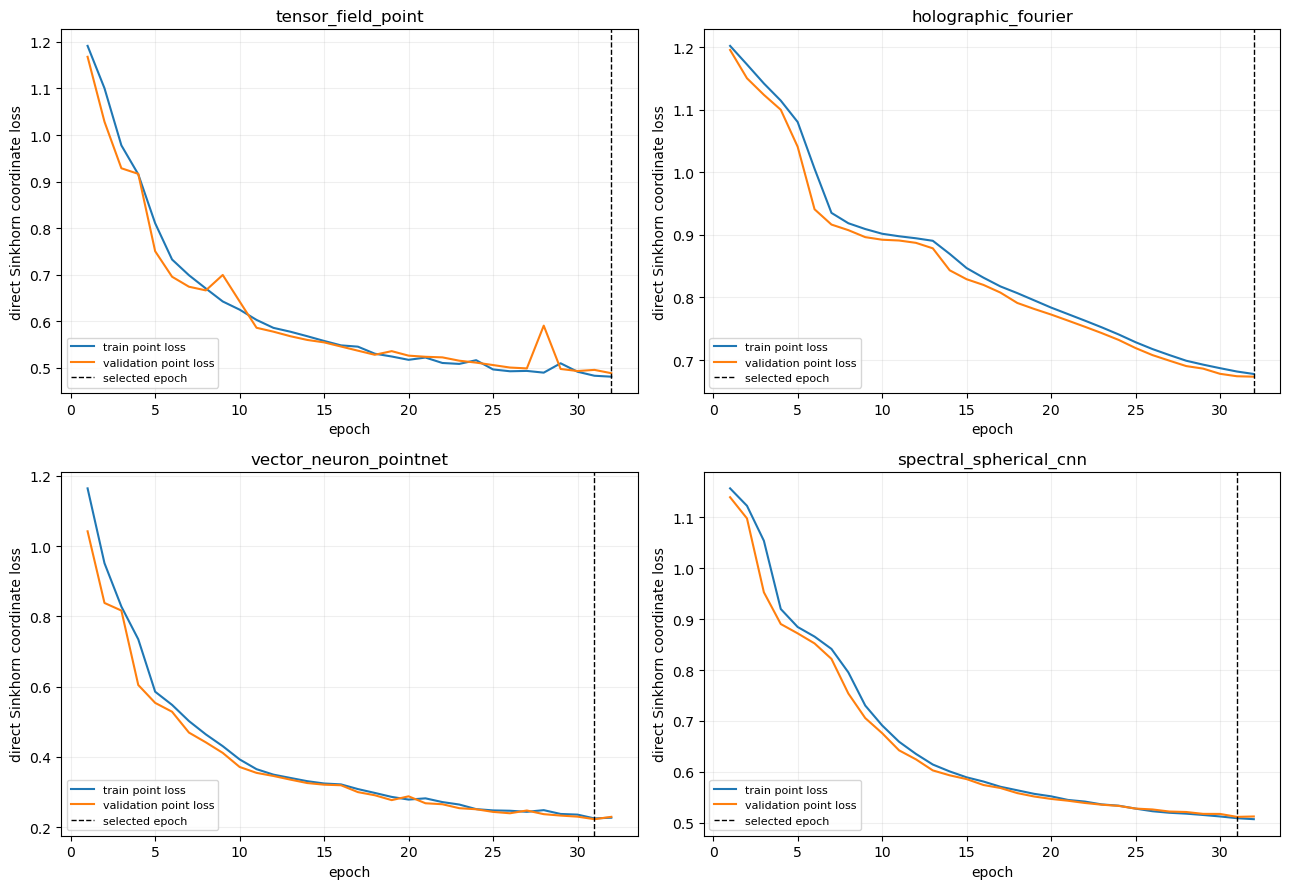

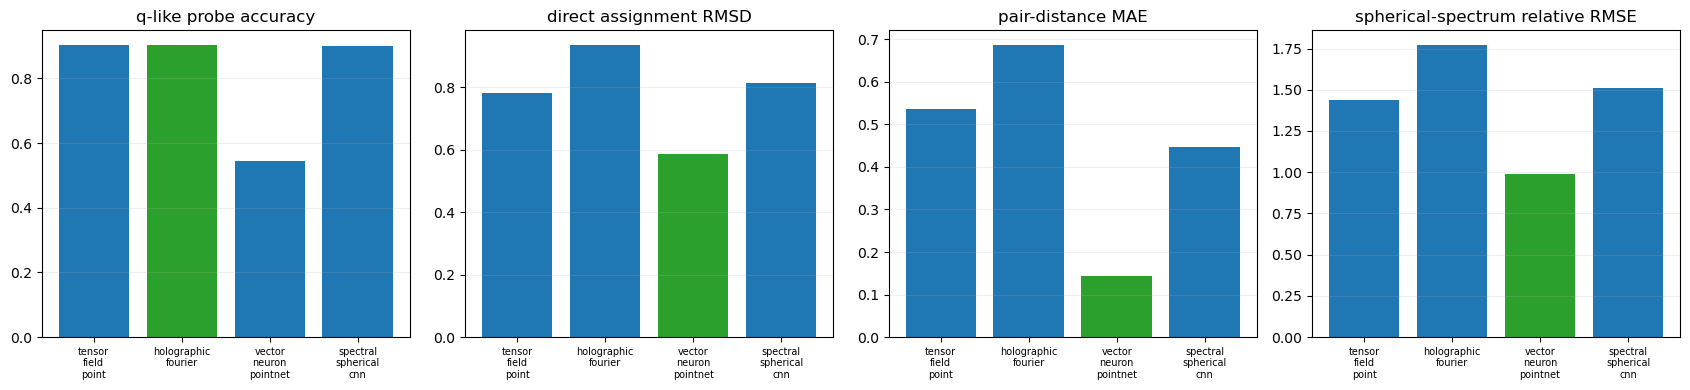

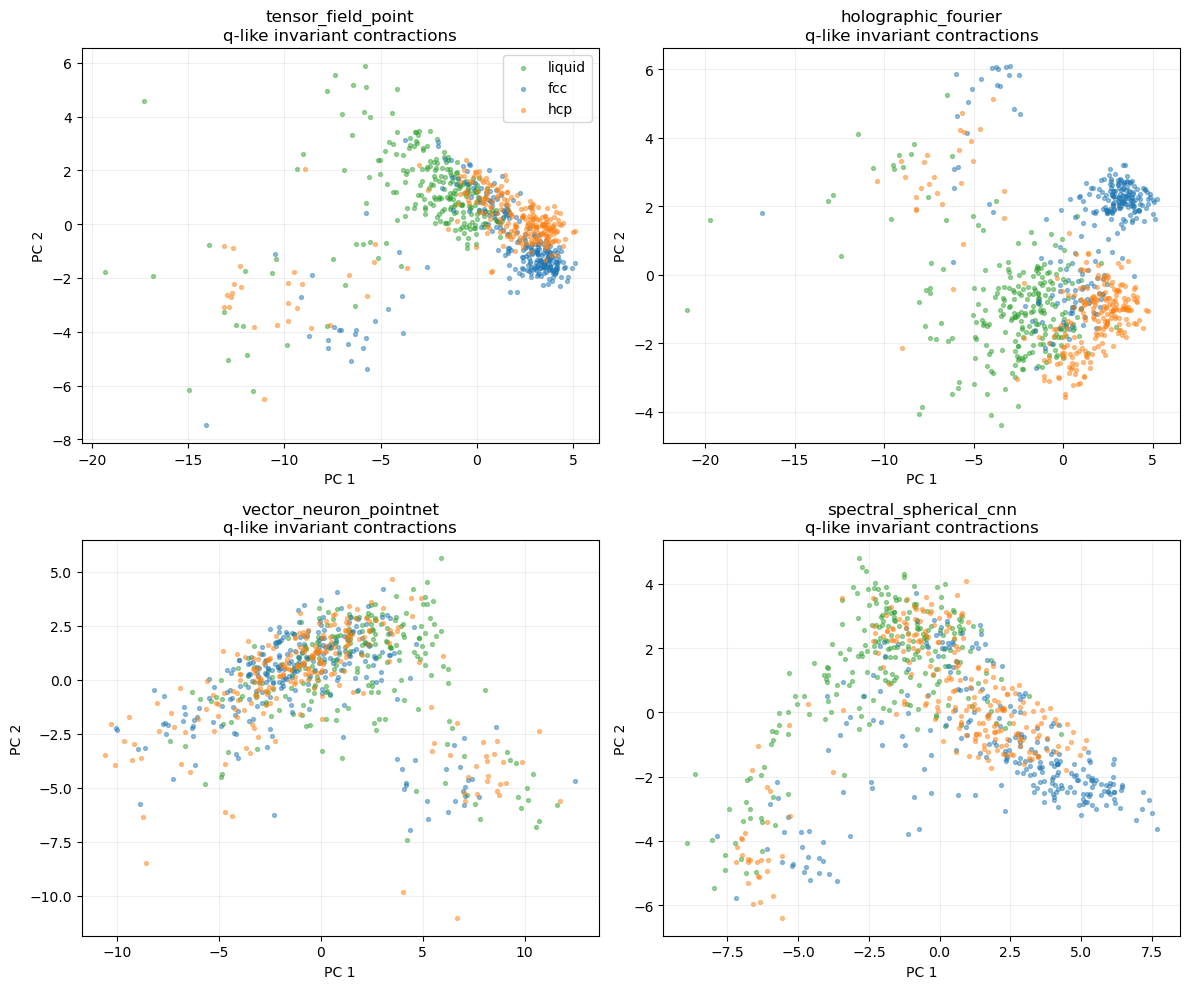

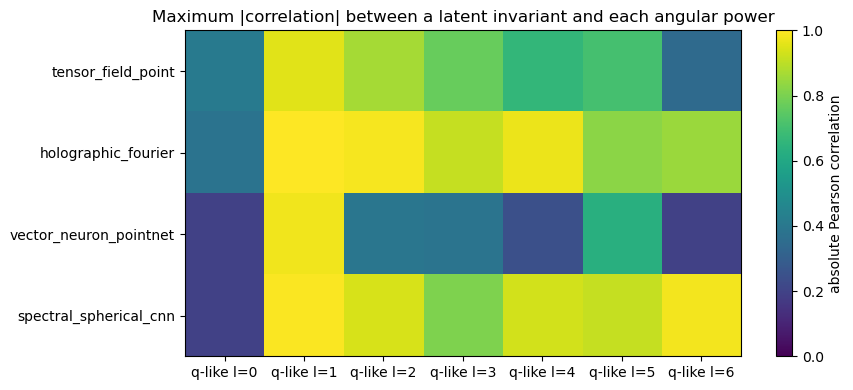

In [29]:
if RUN_EQUIVARIANT_AUTOENCODERS:
    names = list(equivariant_artifacts)
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), squeeze=False)
    for ax, name in zip(axes.ravel(), names):
        history = equivariant_artifacts[name]["history"]
        ax.plot(history["epoch"], history["train_point_loss"], label="train point loss")
        ax.plot(history["epoch"], history["val_point_loss"], label="validation point loss")
        ax.axvline(
            equivariant_artifacts[name]["best_epoch"], color="black",
            linestyle="--", linewidth=1, label="selected epoch"
        )
        ax.set(title=name, xlabel="epoch", ylabel="direct Sinkhorn coordinate loss")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    ordered = equivariant_results.set_index("model").loc[names]
    metrics = (
        ("q_like_probe_balanced_accuracy", "q-like probe accuracy", False),
        ("direct_assignment_RMSD", "direct assignment RMSD", True),
        ("pair_distance_MAE", "pair-distance MAE", True),
        ("spectral_relative_RMSE", "spherical-spectrum relative RMSE", True),
    )
    fig, axes = plt.subplots(1, 4, figsize=(17, 4))
    for ax, (column, title, lower_is_better) in zip(axes, metrics):
        values = ordered[column]
        colors = ["tab:green" if value == (values.min() if lower_is_better else values.max())
                  else "tab:blue" for value in values]
        ax.bar(np.arange(len(names)), values, color=colors)
        ax.set_xticks(np.arange(len(names)), [name.replace("_", "\n") for name in names], fontsize=7)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), squeeze=False)
    test = dataset["split"] == "test"
    train = dataset["split"] == "train"
    for ax, name in zip(axes.ravel(), names):
        invariant_latent = equivariant_derived[name]["invariant_latent"]
        scaler = StandardScaler().fit(invariant_latent[train])
        scaled = scaler.transform(invariant_latent)
        pca = PCA(n_components=2, random_state=EQ_SEED).fit(scaled[train])
        embedding = pca.transform(scaled)
        for phase in PHASES:
            mask = test & (dataset["labels"] == LABEL_MAP[phase])
            ax.scatter(
                embedding[mask, 0], embedding[mask, 1], s=8, alpha=0.45,
                color=LABEL_COLORS[phase], label=phase
            )
        ax.set(
            title=f"{name}\nq-like invariant contractions",
            xlabel="PC 1", ylabel="PC 2"
        )
        ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

    q_correlation = np.stack([
        equivariant_derived[name]["max_q_correlation"] for name in names
    ])
    fig, ax = plt.subplots(figsize=(9, 4))
    image = ax.imshow(q_correlation, vmin=0, vmax=1, cmap="viridis", aspect="auto")
    ax.set_xticks(np.arange(EQ_LMAX + 1), [f"q-like l={degree}" for degree in range(EQ_LMAX + 1)])
    ax.set_yticks(np.arange(len(names)), names)
    ax.set_title("Maximum |correlation| between a latent invariant and each angular power")
    fig.colorbar(image, ax=ax, label="absolute Pearson correlation")
    plt.tight_layout()
    plt.show()



## 15. Oriented point reconstructions and angular spectra

Predictions below are shown in the original test orientation.  No Kabsch
alignment is applied.  Each panel selects the median direct-RMSD example of
that phase, preventing cherry-picking of the best reconstruction.



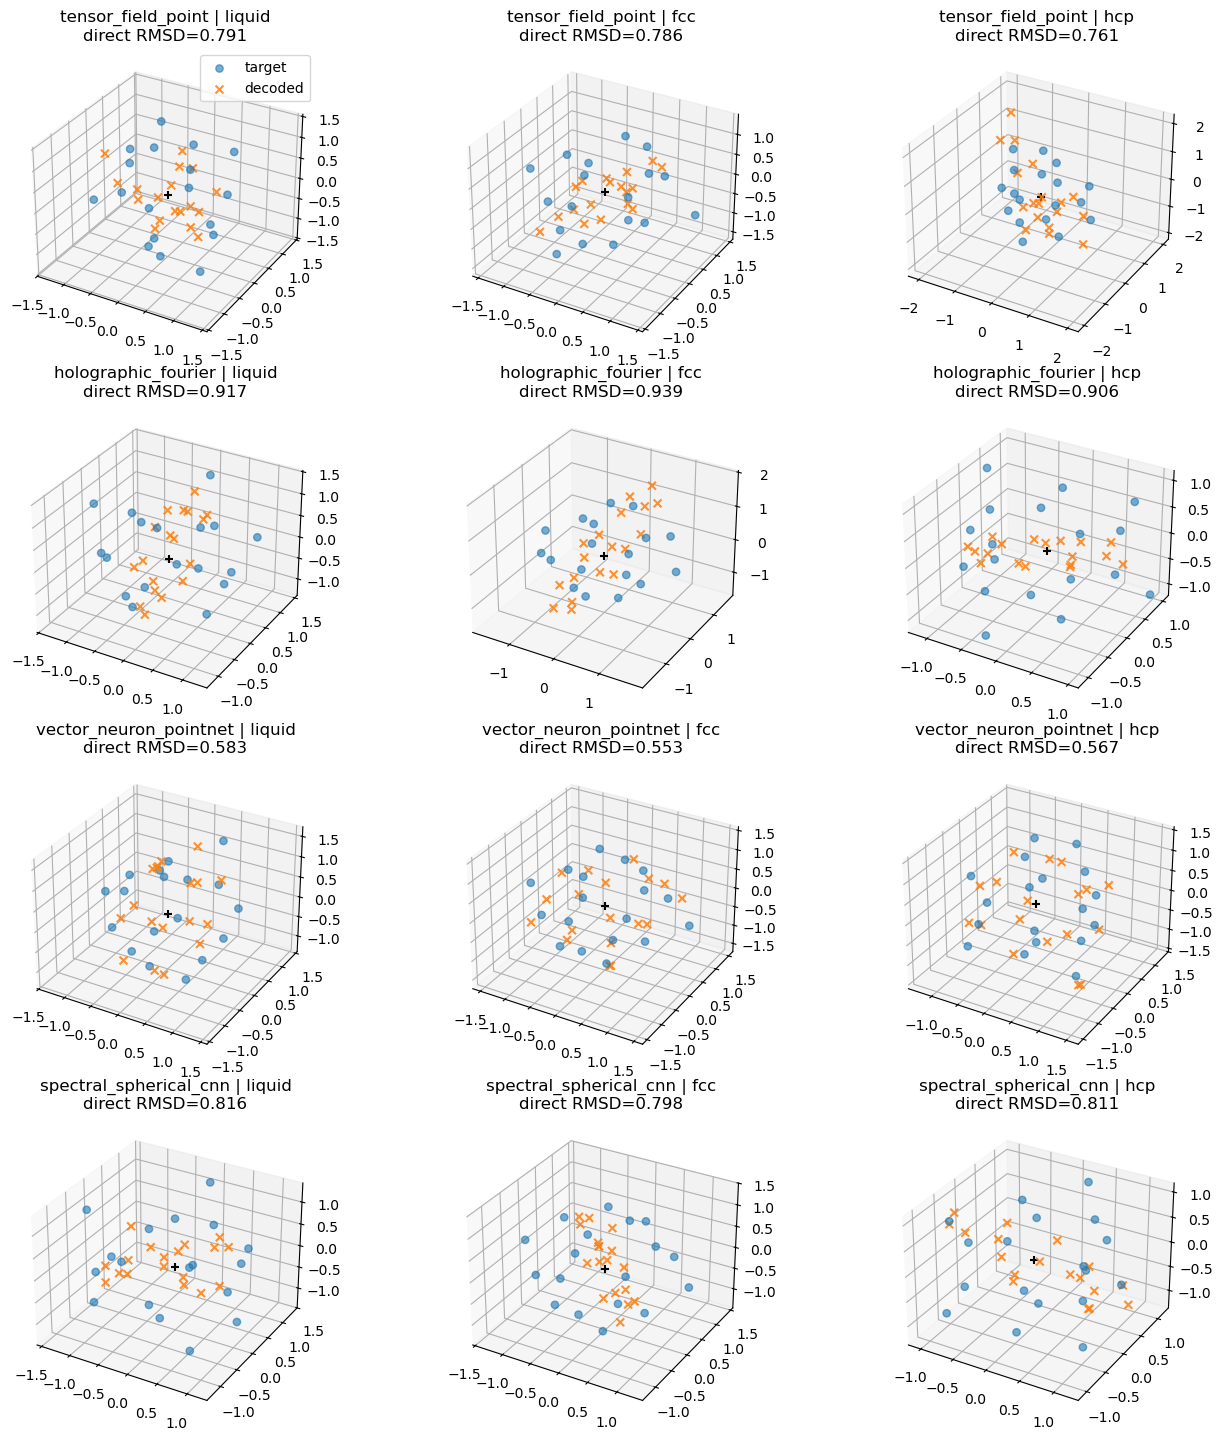

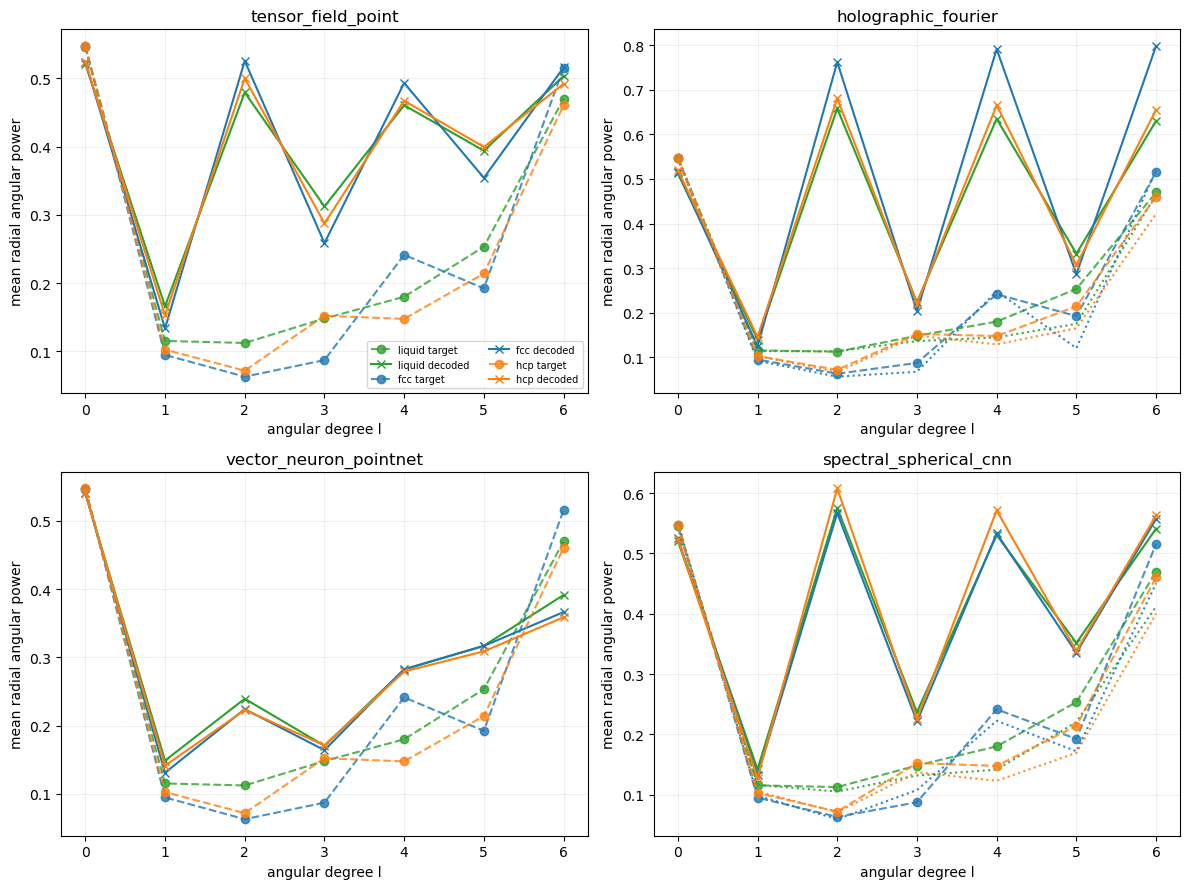

In [30]:
if RUN_EQUIVARIANT_AUTOENCODERS:
    names = list(equivariant_artifacts)
    physical_scale = dataset["coordinate_scale"]
    fig = plt.figure(figsize=(14, 3.6 * len(names)))
    for row, name in enumerate(names):
        info = equivariant_derived[name]
        indices = info["test_indices"]
        selected_labels = dataset["labels"][indices]
        rmsds = info["direct_rmsd"]
        for column, phase in enumerate(PHASES):
            local = np.flatnonzero(selected_labels == LABEL_MAP[phase])
            chosen = local[np.argsort(rmsds[local])[len(local) // 2]]
            _, matched_prediction, matched_target = info["assignment_results"][chosen]
            matched_prediction = matched_prediction * physical_scale
            matched_target = matched_target * physical_scale
            ax = fig.add_subplot(
                len(names), len(PHASES), row * len(PHASES) + column + 1,
                projection="3d"
            )
            ax.scatter(*matched_target[1:].T, s=28, marker="o", alpha=0.6, label="target")
            ax.scatter(*matched_prediction[1:].T, s=32, marker="x", alpha=0.85, label="decoded")
            ax.scatter(0, 0, 0, color="black", marker="+", s=40)
            eq_set_equal_3d_axes(ax, np.concatenate([matched_target, matched_prediction]))
            ax.set_title(
                f"{name} | {phase}\n"
                f"direct RMSD={rmsds[chosen] * physical_scale:.3f}"
            )
            if row == 0 and column == 0:
                ax.legend()
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), squeeze=False)
    for ax, name in zip(axes.ravel(), names):
        info = equivariant_derived[name]
        selected_labels = dataset["labels"][info["test_indices"]]
        predicted = torch.from_numpy(info["predicted_coefficients"])
        target = torch.from_numpy(info["target_coefficients"])
        predicted_power = eq_expansion_for_evaluation.angular_power(predicted).numpy()
        target_power = eq_expansion_for_evaluation.angular_power(target).numpy()
        native_power = None
        if info["native_coefficients"] is not None:
            native_power = eq_expansion_for_evaluation.angular_power(
                torch.from_numpy(info["native_coefficients"])
            ).numpy()
        for phase in PHASES:
            mask = selected_labels == LABEL_MAP[phase]
            color = LABEL_COLORS[phase]
            ax.plot(
                range(EQ_LMAX + 1), target_power[mask].mean(axis=0),
                color=color, linestyle="--", marker="o", alpha=0.8,
                label=f"{phase} target"
            )
            ax.plot(
                range(EQ_LMAX + 1), predicted_power[mask].mean(axis=0),
                color=color, linestyle="-", marker="x", label=f"{phase} decoded"
            )
            if native_power is not None:
                ax.plot(
                    range(EQ_LMAX + 1), native_power[mask].mean(axis=0),
                    color=color, linestyle=":", alpha=0.9,
                    label=f"{phase} native coefficients"
                )
        ax.set(title=name, xlabel="angular degree l", ylabel="mean radial angular power")
        ax.set_xticks(range(EQ_LMAX + 1))
        ax.grid(alpha=0.2)
    axes[0, 0].legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()



## 16. How to choose the next model

1. Reject a run unless latent, point-output, and (where present) coefficient
   equivariance errors are near floating-point tolerance.
2. Use direct assignment RMSD as the primary reconstruction metric; unlike the
   earlier aligned RMSD, it penalizes an incorrectly oriented reconstruction.
3. Inspect median oriented clouds and angular-power curves for prototype
   collapse or missing high-$l$ structure.
4. Treat phase-probe accuracy and q-like PCA as secondary representation
   diagnostics, not as reconstruction metrics.
5. If the Fourier/spherical models reconstruct coefficients but not points,
   improve the common point decoder before increasing encoder capacity.
6. A low reconstruction-diversity ratio signals prototype/zero collapse.  A
   fixed-slot equivariant decoder can be fundamentally awkward at exactly
   symmetric clouds because no continuous, symmetry-respecting particle
   labeling exists; in that case prefer the coefficient/density output.
7. After selecting one or two viable clean models, run multiple seeds and only
   then reintroduce denoising and masked-neighbor objectives.
